# Lista 3 - RNN, LSTM, GRU e Transformers
**Aluno:** Vitor Fontenele de Oliveira Linhares

**Mátricula:** 1700778

## Imports

In [ ]:
import numpy as np
import pandas as pd
import re
from collections import Counter
import copy

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset

from datasets import load_dataset
from tqdm.auto import tqdm

from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Questão 1: RNN - AG News

### Exploração e Entendimento Inicial do Dataset

In [3]:
ds = load_dataset("sh0416/ag_news")

print(ds)

df_train_raw = pd.DataFrame(ds["train"])
df_test_raw = pd.DataFrame(ds["test"])

id2label = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}

def normalize_label_to_one_based(label_series):
    unique_vals = set(label_series.unique())
    if unique_vals.issubset({1, 2, 3, 4}):
        return label_series.astype(int)
    if unique_vals.issubset({0, 1, 2, 3}):
        return (label_series.astype(int) + 1)
    raise ValueError(f"Labels fora do esperado: {sorted(unique_vals)}")

def build_exploration_df(df_raw):
    needed_cols = {"label", "title", "description"}
    if not needed_cols.issubset(df_raw.columns):
        raise ValueError("Dataset nao possui as colunas esperadas: label, title e description.")

    df = df_raw[["label", "title", "description"]].copy()
    label_id = normalize_label_to_one_based(df["label"])
    df["label"] = label_id.map(id2label)
    df["text"] = (df["title"].astype(str).str.strip() + " " + df["description"].astype(str).str.strip()).str.strip()

    df = df[["label", "text"]].reset_index(drop=True)
    df.insert(0, "id", df.index + 1)
    return df

df_train = build_exploration_df(df_train_raw)
df_test = build_exploration_df(df_test_raw)

print("\nPrimeiras linhas:")
display(df_train[["id", "label", "text"]].head(3))

train_counts = df_train["label"].value_counts().reindex(["World", "Sports", "Business", "Sci/Tech"], fill_value=0)
test_counts = df_test["label"].value_counts().reindex(["World", "Sports", "Business", "Sci/Tech"], fill_value=0)

dist_df = pd.DataFrame({
    "label": train_counts.index,
    "train_count": train_counts.values,
    "test_count": test_counts.values,
})
dist_df["train_pct"] = (dist_df["train_count"] / len(df_train) * 100).round(2)
dist_df["test_pct"] = (dist_df["test_count"] / len(df_test) * 100).round(2)

print("\nDistribuicao por classe:")
display(dist_df)

sample_df = df_train.sample(n=min(20000, len(df_train)), random_state=42).copy()
sample_df["text_n_words"] = sample_df["text"].astype(str).str.split().str.len()

print("\nEstatisticas de tamanho de text:")
display(sample_df[["text_n_words"]].describe().T)

example_parts = []
for label_name in ["World", "Sports", "Business", "Sci/Tech"]:
    class_df = df_train[df_train["label"] == label_name]
    class_sample = class_df.sample(n=min(1, len(class_df)), random_state=42)
    example_parts.append(class_sample)

examples = pd.concat(example_parts, ignore_index=True).sort_values("label").reset_index(drop=True)

print("\nExemplos de noticias por classe:")
display(examples[["id", "label", "text"]])

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 7600
    })
})

Primeiras linhas:


,id,label,text
0,1,Business,Wall St. Bears Claw Back Into the Black (Reute...
1,2,Business,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Business,Oil and Economy Cloud Stocks' Outlook (Reuters...



Distribuicao por classe:


,label,train_count,test_count,train_pct,test_pct
0,World,30000,1900,25.0,25.0
1,Sports,30000,1900,25.0,25.0
2,Business,30000,1900,25.0,25.0
3,Sci/Tech,30000,1900,25.0,25.0



Estatisticas de tamanho de text:


,count,mean,std,min,25%,50%,75%,max
text_n_words,20000.0,37.7904,10.140711,9.0,32.0,37.0,43.0,171.0



Exemplos de noticias por classe:


,id,label,text
0,9286,Business,US house sales fall in July Sales of non-new h...
1,9048,Sci/Tech,Gartner optimistic about chip numbers But that...
2,9827,Sports,Second Andre win in a row boosts US gold medal...
3,8898,World,"Explosion Rocks Baghdad Neighborhood BAGHDAD, ..."


###  Parâmetros e Configuração

In [60]:
rnn_static_config = {
    "data": {
        "label2target": {"World": 0, "Sports": 1, "Business": 2, "Sci/Tech": 3},
        "val_size": 0.15,
        "random_state": 42,
        "min_freq": 2,
        "max_vocab_size": 2000,
        "special_tokens": ["<pad>", "<unk>"],
        "max_len_percentile": 95,
        "max_len_min": 16,
        "max_len_cap": 96,
        "batch_size": 256,
    },
    "train": {
        "epochs": 5,
        "learning_rate": 1e-3,
        "weight_decay": 2e-5,
        "grad_clip": 1.0,
        "early_stopping_patience": 2,
        "show_progress": True,
    },
}

rnn_model_configs = [
    {
        "name": "Config A",
        "model": {
            "embedding_dim": 64,
            "hidden_size": 64,
            "num_layers": 1,
            "nonlinearity": "tanh",
            "dropout": 0.0,
            "bidirectional": False,
        },
    },
    {
        "name": "Config B",
        "model": {
            "embedding_dim": 160,
            "hidden_size": 256,
            "num_layers": 2,
            "nonlinearity": "relu",
            "dropout": 0.3,
            "bidirectional": True,
        },
    },
]

print("\nConfiguração fixa:\n")
for section_name in ["data", "train"]:
    print(f"[{section_name}]")
    for k, v in rnn_static_config[section_name].items():
        print(f"- {k}: {v}")
    print()

model_cfg_by_name = {}
for i, cfg_item in enumerate(rnn_model_configs):
    cfg_name = cfg_item.get("name", f"Config {i}")
    model_cfg_by_name[cfg_name] = cfg_item["model"]
model_cfg_df = pd.DataFrame(model_cfg_by_name)

print("Comparação de modelos:")
display(model_cfg_df)


Configuração fixa:

[data]
- label2target: {'World': 0, 'Sports': 1, 'Business': 2, 'Sci/Tech': 3}
- val_size: 0.15
- random_state: 42
- min_freq: 2
- max_vocab_size: 2000
- special_tokens: ['<pad>', '<unk>']
- max_len_percentile: 95
- max_len_min: 16
- max_len_cap: 96
- batch_size: 256

[train]
- epochs: 5
- learning_rate: 0.001
- weight_decay: 2e-05
- grad_clip: 1.0
- early_stopping_patience: 2
- show_progress: True

Comparação de modelos:


,Config A,Config B
embedding_dim,64,160
hidden_size,64,256
num_layers,1,2
nonlinearity,tanh,relu
dropout,0.0,0.3
bidirectional,False,True


### Pré-processamento para RNN 

In [46]:
df_train_model = df_train[["text", "label"]].copy()
df_test_model = df_test[["text", "label"]].copy()

label2target = rnn_static_config["data"]["label2target"]
df_train_model["target"] = df_train_model["label"].map(label2target)
df_test_model["target"] = df_test_model["label"].map(label2target)

if df_train_model["target"].isna().any() or df_test_model["target"].isna().any():
    raise ValueError("Foram encontrados labels fora do mapeamento esperado.")

train_df, val_df = train_test_split(
    df_train_model,
    test_size=rnn_static_config["data"]["val_size"],
    random_state=rnn_static_config["data"]["random_state"],
    stratify=df_train_model["target"]
)

print("Shapes dos splits:")
print(f"train: {train_df.shape} | val: {val_df.shape} | test: {df_test_model.shape}")

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

counter = Counter()
for txt in train_df["text"]:
    counter.update(tokenize(txt))

min_freq = rnn_static_config["data"]["min_freq"]
max_vocab_size = rnn_static_config["data"]["max_vocab_size"]
special_tokens = rnn_static_config["data"]["special_tokens"]

vocab_tokens = [tok for tok, freq in counter.items() if freq >= min_freq]
vocab_tokens = sorted(vocab_tokens, key=lambda t: counter[t], reverse=True)
vocab_tokens = vocab_tokens[:max_vocab_size - len(special_tokens)]

itos = special_tokens + vocab_tokens
stoi = {tok: idx for idx, tok in enumerate(itos)}

PAD_IDX = stoi["<pad>"]
UNK_IDX = stoi["<unk>"]

def encode_text(text):
    return [stoi.get(tok, UNK_IDX) for tok in tokenize(text)]

train_df = train_df.copy()
val_df = val_df.copy()
test_df = df_test_model.copy()

train_df["seq"] = train_df["text"].map(encode_text)
val_df["seq"] = val_df["text"].map(encode_text)
test_df["seq"] = test_df["text"].map(encode_text)

train_lengths = train_df["seq"].map(len).values
max_len = int(np.percentile(train_lengths, rnn_static_config["data"]["max_len_percentile"]))
max_len = max(rnn_static_config["data"]["max_len_min"], min(max_len, rnn_static_config["data"]["max_len_cap"]))

def pad_or_truncate(seq, max_len, pad_idx=PAD_IDX):
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [pad_idx] * (max_len - len(seq))

X_train = np.array([pad_or_truncate(s, max_len) for s in train_df["seq"]], dtype=np.int64)
X_val = np.array([pad_or_truncate(s, max_len) for s in val_df["seq"]], dtype=np.int64)
X_test = np.array([pad_or_truncate(s, max_len) for s in test_df["seq"]], dtype=np.int64)

y_train = train_df["target"].to_numpy(dtype=np.int64)
y_val = val_df["target"].to_numpy(dtype=np.int64)
y_test = test_df["target"].to_numpy(dtype=np.int64)

batch_size = rnn_static_config["data"]["batch_size"]
pin_memory = device.type == "cuda"
loader_kwargs = {"batch_size": batch_size, "pin_memory": pin_memory}

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.long),
    torch.tensor(y_train, dtype=torch.long)
)
val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.long),
    torch.tensor(y_val, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.long),
    torch.tensor(y_test, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

Shapes dos splits:
train: (102000, 3) | val: (18000, 3) | test: (7600, 3)


### RNN

In [110]:
num_classes = len(rnn_static_config["data"]["label2target"])

class NewsRNNClassifier(nn.Module):
    def __init__(self, vocab_size, pad_idx, cfg):
        super().__init__()
        model_cfg = cfg["model"]

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=model_cfg["embedding_dim"],
            padding_idx=pad_idx,
        )

        effective_dropout = model_cfg["dropout"] if model_cfg["num_layers"] > 1 else 0.0

        self.rnn = nn.RNN(
            input_size=model_cfg["embedding_dim"],
            hidden_size=model_cfg["hidden_size"],
            num_layers=model_cfg["num_layers"],
            nonlinearity=model_cfg["nonlinearity"],
            batch_first=True,
            dropout=effective_dropout,
            bidirectional=model_cfg["bidirectional"],
        )

        out_dim = model_cfg["hidden_size"] * (2 if model_cfg["bidirectional"] else 1)
        self.fc = nn.Linear(out_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        _, h_n = self.rnn(emb)

        if self.rnn.bidirectional:
            h_last = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            h_last = h_n[-1]

        logits = self.fc(h_last)
        return logits


def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    grad_clip=None,
    max_batches=None,
    progress_bar=None,
):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_examples = 0
    all_preds = []
    all_targets = []

    for batch_idx, (xb, yb) in enumerate(loader):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        batch_size = yb.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(yb.detach().cpu().numpy())

        if progress_bar is not None and is_train:
            progress_bar.update(1)

        if max_batches is not None and (batch_idx + 1) >= max_batches:
            break

    avg_loss = total_loss / max(total_examples, 1)
    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, average="macro", zero_division=0)
    rec = recall_score(all_targets, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

    return {
        "loss": avg_loss,
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }


def build_cfg_from_rnn_config(base_cfg, config_item):
    if "model" not in config_item:
        raise ValueError("Cada item de rnn_configs precisa ter a chave 'model'.")

    return {
        "name": config_item.get("name", "Config"),
        "data": copy.deepcopy(base_cfg["data"]),
        "train": copy.deepcopy(base_cfg["train"]),
        "model": copy.deepcopy(config_item["model"]),
    }


def train_rnn_experiment(cfg, verbose=False):
    model = NewsRNNClassifier(vocab_size=len(itos), pad_idx=PAD_IDX, cfg=cfg).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=cfg["train"]["learning_rate"],
        weight_decay=cfg["train"]["weight_decay"],
    )

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_f1": [], "val_f1": [],
    }

    max_train_batches = cfg["train"].get("max_train_batches")
    max_eval_batches = cfg["train"].get("max_eval_batches")
    show_progress = cfg["train"].get("show_progress", False)

    best_val_loss = float("inf")
    best_state = None
    patience = 0

    total_epochs = cfg["train"]["epochs"]
    cfg_name = cfg.get("name", "Config")

    progress_bar = None
    if show_progress:
        train_steps_total = len(train_loader)
        if max_train_batches is not None:
            train_steps_total = min(train_steps_total, int(max_train_batches))
        total_steps = max(1, total_epochs * train_steps_total)
        progress_bar = tqdm(
            total=total_steps,
            desc=f"{cfg_name}",
            leave=True,
            dynamic_ncols=True,
            unit="batch",
        )

    for epoch in range(1, total_epochs + 1):

        train_metrics = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            grad_clip=cfg["train"]["grad_clip"],
            max_batches=max_train_batches,
            progress_bar=progress_bar,
        )
        val_metrics = run_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None,
            max_batches=max_eval_batches,
            progress_bar=None,
        )

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(train_metrics["acc"])
        history["val_acc"].append(val_metrics["acc"])
        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])

        if verbose:
            print(
                f"Epoch {epoch:02d}/{cfg['train']['epochs']} | "
                f"train_loss={train_metrics['loss']:.4f} val_loss={val_metrics['loss']:.4f} | "
                f"train_acc={train_metrics['acc']:.4f} val_acc={val_metrics['acc']:.4f} | "
                f"val_f1={val_metrics['f1']:.4f}"
            )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= cfg["train"]["early_stopping_patience"]:
                if verbose:
                    print("Early stopping acionado.")
                break

    if progress_bar is not None:
        progress_bar.close()

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = run_epoch(
        model,
        test_loader,
        criterion,
        optimizer=None,
        max_batches=max_eval_batches,
        progress_bar=None,
    )

    all_preds = []
    all_targets = []
    model.eval()
    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(test_loader):
            xb = xb.to(device, non_blocking=True)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(yb.numpy())

            if max_eval_batches is not None and (batch_idx + 1) >= max_eval_batches:
                break

    cm = confusion_matrix(all_targets, all_preds)
    label_order = ["World", "Sports", "Business", "Sci/Tech"]
    cm_df = pd.DataFrame(cm, index=[f"Real {x}" for x in label_order], columns=[f"Pred {x}" for x in label_order])

    return {
        "model": model,
        "history": history,
        "test_metrics": test_metrics,
        "confusion_matrix": cm,
        "confusion_matrix_df": cm_df,
        "label_order": label_order,
        "used_cfg": cfg,
    }

### Rodando os Experimentos

In [111]:
experiment_runs = {}
for i, cfg_item in enumerate(rnn_model_configs):
    cfg_name = cfg_item.get("name", f"Config {i}")
    exp_cfg = build_cfg_from_rnn_config(rnn_static_config, cfg_item)
    experiment_runs[cfg_name] = train_rnn_experiment(cfg=exp_cfg, verbose=False)

Config B: 100%|██████████| 1995/1995 [04:37<00:00,  7.19batch/s]


### Resultados

Metricas:


config,loss,accuracy,precision_macro,recall_macro,f1_macro
Config A,1.162872,0.438289,0.448196,0.438289,0.321661
Config B,0.338871,0.882763,0.885462,0.882763,0.882594


Matrizes de confusão (uma por config):

Config A


,Pred World,Pred Sports,Pred Business,Pred Sci/Tech
Real World,15,462,31,1392
Real Sports,4,1590,5,301
Real Business,9,160,48,1683
Real Sci/Tech,12,180,30,1678



Config B


,Pred World,Pred Sports,Pred Business,Pred Sci/Tech
Real World,1619,64,102,115
Real Sports,31,1828,14,27
Real Business,57,34,1539,270
Real Sci/Tech,43,38,96,1723


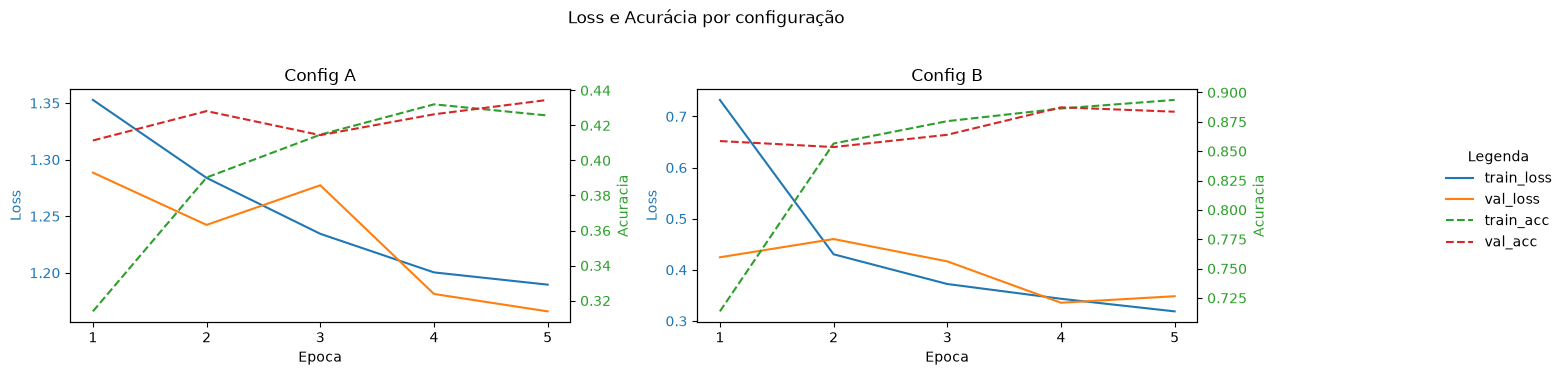

In [112]:
rows = []
for cfg_name, run in experiment_runs.items():
    tm = run["test_metrics"]
    rows.append({
        "config": cfg_name,
        "loss": tm["loss"],
        "accuracy": tm["acc"],
        "precision_macro": tm["precision"],
        "recall_macro": tm["recall"],
        "f1_macro": tm["f1"],
    })
metrics_df = pd.DataFrame(rows)

print("Metricas:")
display(metrics_df.style.hide(axis="index"))

print("Matrizes de confusão (uma por config):")
for cfg_name, run in experiment_runs.items():
    print(f"\n{cfg_name}")
    display(run["confusion_matrix_df"])

cfg_names = list(experiment_runs.keys())
n_cfg = len(cfg_names)
fig, axes = plt.subplots(1, n_cfg, figsize=(7.2 * n_cfg, 3.6), squeeze=False)
axes = axes[0]

legend_handles = None
legend_labels = None

for i, cfg_name in enumerate(cfg_names):
    run = experiment_runs[cfg_name]
    history = run["history"]
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    ax1 = axes[i]
    ln1 = ax1.plot(epochs, history["train_loss"], label="train_loss", color="tab:blue")
    ln2 = ax1.plot(epochs, history["val_loss"], label="val_loss", color="tab:orange")
    ax1.set_xlabel("Epoca")
    ax1.set_ylabel("Loss", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.set_xticks(epochs)

    ax2 = ax1.twinx()
    ln3 = ax2.plot(epochs, history["train_acc"], label="train_acc", color="tab:green", linestyle="--")
    ln4 = ax2.plot(epochs, history["val_acc"], label="val_acc", color="tab:red", linestyle="--")
    ax2.set_ylabel("Acuracia", color="tab:green")
    ax2.tick_params(axis="y", labelcolor="tab:green")

    if legend_handles is None:
        legend_handles = ln1 + ln2 + ln3 + ln4
        legend_labels = [l.get_label() for l in legend_handles]

    ax1.set_title(cfg_name)

fig.suptitle("Loss e Acurácia por configuração", y=1.03)
fig.legend(
    legend_handles,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(1.005, 0.5),
    frameon=False,
    title="Legenda",
)

plt.tight_layout(rect=(0, 0, 0.9, 1))
plt.show()

### Análise & Discussão

Este problema trata da classificação do tema de uma notícia (World, Sports, Business, Sci/Tech), portanto é uma tarefa de classificação multiclasse supervisionada. Diferente da classificação binária, aqui trabalhamos com 4 classes e a decisão final é feita entre múltiplos rótulos, o que influencia a escolha das funções de perda e métricas. Como o dado é texto, tratamos a entrada como sequência, visto que a ordem dos tokens importa para interpretação de contexto e para a decisão da classe predita. Além disso, é necessário converter o texto em uma representação numérica (embedding) para que a RNN possa processar, já que ela opera sobre vetores e não sobre texto, o que tem relação com o fato de computadores processarem números e não palavras. O embedding é uma forma de mapear palavras para um espaço vetorial, onde palavras com significados semelhantes ficam próximas.

Primeiro foi feita uma exploração inicial do dataset para entender estrutura, distribuição das classes e formato dos campos. Em seguida, o texto foi preparado para a RNN com normalização, tokenização, construção de vocabulário, mapeamento para índices, truncamento/padding e criação dos DataLoaders. Em poucas palavras: o embedding projeta tokens para um espaço vetorial, e o padding permite batch com tamanhos uniformes.

Uma limitação das RNNs é a dificuldade de capturar dependências muito longas (gradientes tendem a se degradar ao longo do tempo). Esse tipo de limitação motivou arquiteturas como LSTM e GRU. Ainda assim, para texto sequencial, RNN é mais adequada que MLP: na MLP cada entrada é tratada sem memória temporal explícita, enquanto a RNN carrega estado entre passos da sequência.

Para comparação justa de arquitetura, mantive as configurações de dados e treino fixas (`rnn_static_config`) e alterei apenas os parâmetros do modelo (`rnn_model_configs`) entre `Config A` e `Config B`.

1. Quais classes foram mais acertadas?
- Na `Config A`, as classes com melhor acerto foram Sports e Sci/Tech.
- Na `Config B`, Sports e Sci/Tech continuam fortes, e World e Business melhoram bastante em relação à `Config A`.

2. Quais classes foram mais confundidas?
- Na `Config A`, os maiores erros foram World e Business -> Sci/Tech.
- Na `Config B`, a confusão mais recorrente ainda envolve World e Business -> Sci/Tech, porém em escala bem menor.

3. Possíveis causas dos erros
- Ambiguidade semântica entre temas de World, Business e Sci/Tech em parte das notícias.
- Limitações do vocabulário (`max_vocab_size=2000`) e do corte de sequência (`max_len_cap=96`), que podem descartar termos informativos.
- Baixa capacidade da `Config A` para separar fronteiras mais difíceis entre classes.

4. Sinais de underfitting e overfitting
- `Config A`: há sinal claro de underfitting (baixa acurácia geral, macro-F1 baixo e viés claro para prever Sci/Tech, exceto em Sports).
- `Config B`: não há sinal forte de overfitting neste resultado; treino e validação ficam próximos e a generalização no teste é boa, Sci/Tech e Sports continuam com os melhores resultados. Uma acurácia de aproximadamente `88,3%` indica um resultado aceitável e que o modelo é, de fato, utilizável para o problema em questão. 

Em resumo, aumentar a complexidade da rede melhorou de forma relevante a qualidade das previsões sem degradar a generalização observada. As flutuações entre épocas existem, mas não indicam que apenas aumentar épocas resolveria o problema; neste experimento, a escolha de arquitetura teve impacto maior que simplesmente treinar por mais tempo.

## Questão 2: LSTM - IMDb Movie Reviews

### Exploração e Entendimento Inicial do Dataset

In [ ]:
try:
    ds = load_dataset("ajaykarthick/imdb-movie-reviews")
except Exception as e:
    raise RuntimeError(f"Erro ao carregar o dataset 'ajaykarthick/imdb-movie-reviews': {e}")

print(ds)

df_train = pd.DataFrame(ds["train"])
df_test = pd.DataFrame(ds["test"])

print("\nOverview geral:")
print("- colunas:", list(df_train.columns))
print(f"- tamanho train: {df_train.shape} | tamanho test: {df_test.shape}")

if "label" not in df_train.columns or "label" not in df_test.columns:
    raise ValueError("Dataset nao possui a coluna 'label' em train/test.")

def detect_text_column(df_raw):
    text_candidates = ["text", "review", "sentence", "content"]
    for col in text_candidates:
        if col in df_raw.columns:
            return col

    object_cols = [c for c in df_raw.columns if df_raw[c].dtype == "object"]
    if object_cols:
        return object_cols[0]

    raise ValueError("Nao foi possivel identificar uma coluna de texto no dataset.")

text_col = detect_text_column(df_train)
if text_col not in df_test.columns:
    raise ValueError(f"Coluna de texto '{text_col}' nao encontrada no split de teste.")

df_train = df_train[["label", text_col]].rename(columns={text_col: "text"}).reset_index(drop=True)
df_test = df_test[["label", text_col]].rename(columns={text_col: "text"}).reset_index(drop=True)

print("\nValores distintos de label:", sorted(pd.concat([df_train["label"], df_test["label"]]).dropna().unique().tolist()))

expected_labels = {0, 1}
train_label_set = set(df_train["label"].dropna().unique())
test_label_set = set(df_test["label"].dropna().unique())
if not train_label_set.issubset(expected_labels) or not test_label_set.issubset(expected_labels):
    raise ValueError(
        f"Labels inesperados encontrados. train={sorted(train_label_set)} | test={sorted(test_label_set)}"
    )

def validate_no_empty(df, split_name):
    null_label = int(df["label"].isna().sum())
    null_text = int(df["text"].isna().sum())
    empty_text = int(df["text"].astype(str).str.strip().eq("").sum())

    print(f"{split_name}: null_label={null_label}, null_text={null_text}, empty_text={empty_text}")

    if (null_label > 0) or (null_text > 0) or (empty_text > 0):
        raise ValueError(f"Foram encontrados valores vazios em {split_name}.")

print("\nChecagem de valores vazios:")
validate_no_empty(df_train, "train")
validate_no_empty(df_test, "test")

print("\nPrimeiras linhas:")
display(df_train[["label", "text"]].head(3))

train_counts = df_train["label"].value_counts().reindex([0, 1], fill_value=0)
test_counts = df_test["label"].value_counts().reindex([0, 1], fill_value=0)

dist_df = pd.DataFrame({
    "label": train_counts.index,
    "train_count": train_counts.values,
    "test_count": test_counts.values,
})
dist_df["train_pct"] = (dist_df["train_count"] / len(df_train) * 100).round(2)
dist_df["test_pct"] = (dist_df["test_count"] / len(df_test) * 100).round(2)

print("\nDistribuicao por classe (0/1):")
display(dist_df.style.hide(axis="index"))

sample_df = df_train.sample(n=min(20000, len(df_train)), random_state=42).copy()
sample_df["text_n_words"] = sample_df["text"].astype(str).str.split().str.len()

print("\nEstatisticas de tamanho de texto:")
display(sample_df[["text_n_words"]].describe().T)

DatasetDict({
    train: Dataset({
        features: ['review', 'label'],
        num_rows: 40000
    })
    test: Dataset({
        features: ['review', 'label'],
        num_rows: 10000
    })
})

Overview geral:
- colunas: ['review', 'label']
- tamanho train: (40000, 2) | tamanho test: (10000, 2)

Valores distintos de label: [0, 1]

Checagem de valores vazios:
train: null_label=0, null_text=0, empty_text=0
test: null_label=0, null_text=0, empty_text=0

Primeiras linhas (train):


,label,text
0,0,"Ms Aparna Sen, the maker of Mr & Mrs Iyer, dir..."
1,0,"I have seen this film only once, on TV, and it..."
2,1,I was only fourteen when I first saw the Alien...



Distribuicao por classe (0/1):


label,train_count,test_count,train_pct,test_pct
0,20000,5000,50.000000,50.000000
1,20000,5000,50.000000,50.000000



Estatisticas de tamanho de texto:


,count,mean,std,min,25%,50%,75%,max
text_n_words,20000.0,231.63935,170.396298,8.0,126.0,173.0,284.0,2278.0


### Parâmetros e Configuração

In [58]:
lstm_static_config = {
    "data": {
        "label_col": "label",
        "text_col": "text",
        "val_size": 0.15,
        "random_state": 42,
        "clean_text": True,
        "min_freq": 2,
        "max_vocab_size": 30000,
        "special_tokens": ["<pad>", "<unk>"],
        "max_len_percentile": 95,
        "max_len_min": 32,
        "max_len_cap": 300,
        "batch_size": 128,
    },
    "train": {
        "epochs": 5,
        "learning_rate": 1e-3,
        "weight_decay": 1e-5,
        "grad_clip": 1.0,
        "early_stopping_patience": 2,
    },
}

lstm_model_configs = [
    {
        "name": "Config A",
        "model": {
            "embedding_dim": 64,
            "hidden_size": 64,
            "num_layers": 1,
            "dropout": 0.0,
            "bidirectional": False,
        },
    },
    {
        "name": "Config B",
        "model": {
            "embedding_dim": 200,
            "hidden_size": 256,
            "num_layers": 2,
            "dropout": 0.3,
            "bidirectional": True,
        },
    },
]

print("\nConfiguração fixa (LSTM):\n")
for section_name in ["data", "train"]:
    print(f"[{section_name}]")
    for k, v in lstm_static_config[section_name].items():
        print(f"- {k}: {v}")
    print()

model_cfg_by_name = {}
for i, cfg_item in enumerate(lstm_model_configs):
    cfg_name = cfg_item.get("name", f"Config {i}")
    model_cfg_by_name[cfg_name] = cfg_item["model"]
model_cfg_df = pd.DataFrame(model_cfg_by_name)

print("Comparação de modelos (LSTM):")
display(model_cfg_df)


Configuração fixa (LSTM):

[data]
- label_col: label
- text_col: text
- val_size: 0.15
- random_state: 42
- clean_text: True
- min_freq: 2
- max_vocab_size: 30000
- special_tokens: ['<pad>', '<unk>']
- max_len_percentile: 95
- max_len_min: 32
- max_len_cap: 300
- batch_size: 128

[train]
- epochs: 5
- learning_rate: 0.001
- weight_decay: 1e-05
- grad_clip: 1.0
- early_stopping_patience: 2

Comparação de modelos (LSTM):


,Config A,Config B
embedding_dim,64,200
hidden_size,64,256
num_layers,1,2
dropout,0.0,0.3
bidirectional,False,True


### Pré-processamento para LSTM

In [39]:
if "df_train" not in globals() or "df_test" not in globals():
    raise ValueError("Execute a célula de exploração da Questão 2 antes do pré-processamento.")

cfg_data = lstm_static_config["data"]
label_col = cfg_data["label_col"]
text_col = cfg_data["text_col"]

for split_name, df_split in [("train", df_train), ("test", df_test)]:
    missing_cols = {label_col, text_col} - set(df_split.columns)
    if missing_cols:
        raise ValueError(f"Colunas ausentes em {split_name}: {sorted(missing_cols)}")

df_train_model = df_train.copy()
df_test_model = df_test.copy()

for split_name, df_split in [("train", df_train_model), ("test", df_test_model)]:
    null_label = int(df_split[label_col].isna().sum())
    null_text = int(df_split[text_col].isna().sum())
    empty_text = int(df_split[text_col].astype(str).str.strip().eq("").sum())
    if (null_label > 0) or (null_text > 0) or (empty_text > 0):
        raise ValueError(f"Valores vazios encontrados em {split_name}.")

if set(df_train_model[label_col].dropna().unique()) - {0, 1}:
    raise ValueError("Foram encontrados labels fora de 0/1 em train.")
if set(df_test_model[label_col].dropna().unique()) - {0, 1}:
    raise ValueError("Foram encontrados labels fora de 0/1 em test.")

train_df, val_df = train_test_split(
    df_train_model,
    test_size=cfg_data["val_size"],
    random_state=cfg_data["random_state"],
    stratify=df_train_model[label_col],
)

def tokenize(text):
    text = str(text).lower()
    if cfg_data.get("clean_text", True):
        text = re.sub(r"<br\s*/?>", " ", text)
        text = re.sub(r"[^a-z0-9\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
    return text.split()

counter = Counter()
for txt in train_df[text_col]:
    counter.update(tokenize(txt))

min_freq = cfg_data["min_freq"]
max_vocab_size = cfg_data["max_vocab_size"]
special_tokens = cfg_data["special_tokens"]

vocab_tokens = [tok for tok, freq in counter.items() if freq >= min_freq]
vocab_tokens = sorted(vocab_tokens, key=lambda t: counter[t], reverse=True)
vocab_tokens = vocab_tokens[:max_vocab_size - len(special_tokens)]

lstm_itos = special_tokens + vocab_tokens
lstm_stoi = {tok: idx for idx, tok in enumerate(lstm_itos)}

LSTM_PAD_IDX = lstm_stoi["<pad>"]
LSTM_UNK_IDX = lstm_stoi["<unk>"]

def encode_text(text):
    return [lstm_stoi.get(tok, LSTM_UNK_IDX) for tok in tokenize(text)]

train_df = train_df.copy()
val_df = val_df.copy()
test_df = df_test_model.copy()

train_df["seq"] = train_df[text_col].map(encode_text)
val_df["seq"] = val_df[text_col].map(encode_text)
test_df["seq"] = test_df[text_col].map(encode_text)

train_lengths = train_df["seq"].map(len).values
lstm_max_len = int(np.percentile(train_lengths, cfg_data["max_len_percentile"]))
lstm_max_len = max(cfg_data["max_len_min"], min(lstm_max_len, cfg_data["max_len_cap"]))

def pad_or_truncate(seq, max_len, pad_idx=LSTM_PAD_IDX):
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [pad_idx] * (max_len - len(seq))

X_train = np.array([pad_or_truncate(s, lstm_max_len) for s in train_df["seq"]], dtype=np.int64)
X_val = np.array([pad_or_truncate(s, lstm_max_len) for s in val_df["seq"]], dtype=np.int64)
X_test = np.array([pad_or_truncate(s, lstm_max_len) for s in test_df["seq"]], dtype=np.int64)

y_train = train_df[label_col].to_numpy(dtype=np.int64)
y_val = val_df[label_col].to_numpy(dtype=np.int64)
y_test = test_df[label_col].to_numpy(dtype=np.int64)

batch_size = cfg_data["batch_size"]
pin_memory = device.type == "cuda"
loader_kwargs = {"batch_size": batch_size, "pin_memory": pin_memory}

lstm_train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.long),
    torch.tensor(y_train, dtype=torch.long),
)
lstm_val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.long),
    torch.tensor(y_val, dtype=torch.long),
)
lstm_test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.long),
    torch.tensor(y_test, dtype=torch.long),
)

lstm_train_loader = DataLoader(lstm_train_dataset, shuffle=True, **loader_kwargs)
lstm_val_loader = DataLoader(lstm_val_dataset, shuffle=False, **loader_kwargs)
lstm_test_loader = DataLoader(lstm_test_dataset, shuffle=False, **loader_kwargs)

print("Pré-processamento LSTM concluído.")
print(f"splits -> train: {len(y_train)}, val: {len(y_val)}, test: {len(y_test)}")
print(f"vocab_size: {len(lstm_itos)} | max_len: {lstm_max_len} | batch_size: {batch_size}")

Pré-processamento LSTM concluído.
splits -> train: 34000, val: 6000, test: 10000
vocab_size: 30000 | max_len: 300 | batch_size: 128


### LSTM

In [40]:
num_classes = len(np.unique(np.concatenate([y_train, y_val, y_test])))

class SentimentLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, pad_idx, cfg):
        super().__init__()
        model_cfg = cfg["model"]

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=model_cfg["embedding_dim"],
            padding_idx=pad_idx,
        )

        effective_dropout = model_cfg["dropout"] if model_cfg["num_layers"] > 1 else 0.0

        self.lstm = nn.LSTM(
            input_size=model_cfg["embedding_dim"],
            hidden_size=model_cfg["hidden_size"],
            num_layers=model_cfg["num_layers"],
            batch_first=True,
            dropout=effective_dropout,
            bidirectional=model_cfg["bidirectional"],
        )

        out_dim = model_cfg["hidden_size"] * (2 if model_cfg["bidirectional"] else 1)
        self.fc = nn.Linear(out_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        _, (h_n, _) = self.lstm(emb)

        if self.lstm.bidirectional:
            h_last = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            h_last = h_n[-1]

        logits = self.fc(h_last)
        return logits

def run_lstm_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    grad_clip=None,
    max_batches=None,
):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_examples = 0
    all_preds = []
    all_targets = []

    for batch_idx, (xb, yb) in enumerate(loader):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        batch_size = yb.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(yb.detach().cpu().numpy())

        if max_batches is not None and (batch_idx + 1) >= max_batches:
            break

    avg_loss = total_loss / max(total_examples, 1)
    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, zero_division=0)
    rec = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)

    return {
        "loss": avg_loss,
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }

def build_cfg_from_lstm_config(base_cfg, config_item):
    if "model" not in config_item:
        raise ValueError("Cada item de lstm_model_configs precisa ter a chave 'model'.")

    return {
        "name": config_item.get("name", "Config"),
        "data": copy.deepcopy(base_cfg["data"]),
        "train": copy.deepcopy(base_cfg["train"]),
        "model": copy.deepcopy(config_item["model"]),
    }

def train_lstm_experiment(cfg, verbose=False):
    model = SentimentLSTMClassifier(
        vocab_size=len(lstm_itos),
        pad_idx=LSTM_PAD_IDX,
        cfg=cfg,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=cfg["train"]["learning_rate"],
        weight_decay=cfg["train"]["weight_decay"],
    )

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_f1": [], "val_f1": [],
    }

    max_train_batches = cfg["train"].get("max_train_batches")
    max_eval_batches = cfg["train"].get("max_eval_batches")

    best_val_loss = float("inf")
    best_state = None
    patience = 0

    total_epochs = cfg["train"]["epochs"]

    for epoch in range(1, total_epochs + 1):
        train_metrics = run_lstm_epoch(
            model,
            lstm_train_loader,
            criterion,
            optimizer=optimizer,
            grad_clip=cfg["train"]["grad_clip"],
            max_batches=max_train_batches,
        )
        val_metrics = run_lstm_epoch(
            model,
            lstm_val_loader,
            criterion,
            optimizer=None,
            max_batches=max_eval_batches,
        )

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(train_metrics["acc"])
        history["val_acc"].append(val_metrics["acc"])
        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])

        if verbose:
            print(
                f"Epoch {epoch:02d}/{total_epochs} | "
                f"train_loss={train_metrics['loss']:.4f} val_loss={val_metrics['loss']:.4f} | "
                f"train_acc={train_metrics['acc']:.4f} val_acc={val_metrics['acc']:.4f} | "
                f"val_f1={val_metrics['f1']:.4f}"
            )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= cfg["train"]["early_stopping_patience"]:
                if verbose:
                    print("Early stopping acionado.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = run_lstm_epoch(
        model,
        lstm_test_loader,
        criterion,
        optimizer=None,
        max_batches=max_eval_batches,
    )

    all_preds = []
    all_targets = []
    model.eval()
    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(lstm_test_loader):
            xb = xb.to(device, non_blocking=True)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(yb.numpy())

            if max_eval_batches is not None and (batch_idx + 1) >= max_eval_batches:
                break

    cm = confusion_matrix(all_targets, all_preds)
    cm_df = pd.DataFrame(cm, index=["Real 0", "Real 1"], columns=["Pred 0", "Pred 1"])

    return {
        "model": model,
        "history": history,
        "test_metrics": test_metrics,
        "confusion_matrix": cm,
        "confusion_matrix_df": cm_df,
        "used_cfg": cfg,
    }

### Rodando os Experimentos

In [41]:
lstm_experiment_runs = {}
for i, cfg_item in enumerate(lstm_model_configs):
    cfg_name = cfg_item.get("name", f"Config {i}")
    exp_cfg = build_cfg_from_lstm_config(lstm_static_config, cfg_item)
    lstm_experiment_runs[cfg_name] = train_lstm_experiment(cfg=exp_cfg, verbose=False)

### Resultados

Metricas (LSTM):


config,loss,accuracy,precision,recall,f1
Config A,0.640028,0.655700,0.631837,0.746200,0.684273
Config B,0.325583,0.867000,0.865975,0.868400,0.867186


Matrizes de confusão (uma por config):

Config A


,Pred 0,Pred 1
Real 0,2826,2174
Real 1,1269,3731



Config B


...


Exemplo correto:


,true_label,pred_label,text
2,0,0,This was the best movie I've ever seen about B...



Exemplos incorretos:


,true_label,pred_label,text
0,1,0,Essentially plotless action film has two good ...
1,0,1,I grew up on this movie and I can remember whe...
5,0,1,I try to catch this film each time it's shown ...



Textos dos 3 incorretos:
1. Essentially plotless action film has two good guys (Fong and Roundtree) pitted against two bad guys (Mitchell and Pierce). Fong is perhaps the most uncharismatic action lead of the 80s, Roundtree's small part is a far cry from his 'Shaft' days, and Cameron Mitchell adds another shameful role to his career, one to sit right next to his laughable turn in 'The Toolbox Murders' (this man was a respected actor once, now he has come down to wearing flowers in his hair and complaining about people bleeding on his carpet). Only Stack Pierce acts with some dignity. As for the violence, don't worry: most of it is too badly done to offend anyone. (*1/2)

2. I grew up on this movie and I can remember when my brother and I used to play in the backyard and pretend we were in Care-a-lot. Now, after so many years have passed, I get to watch the movie with my daughter and watch her enjoy it. If you are parent and you have not watched this movie with your children, then you 

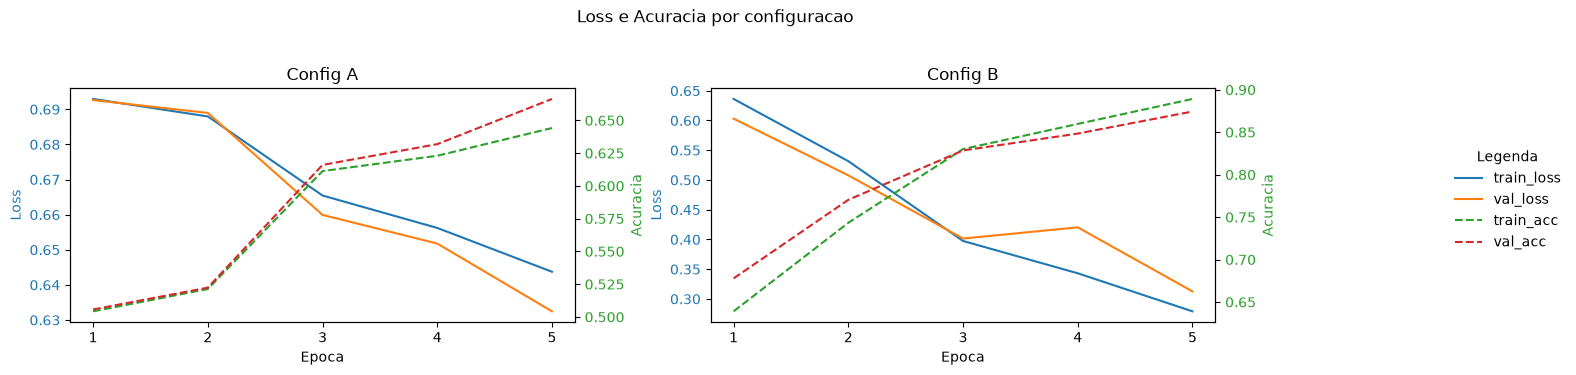

In [ ]:
rows = []
for cfg_name, run in lstm_experiment_runs.items():
    tm = run["test_metrics"]
    rows.append({
        "config": cfg_name,
        "loss": tm["loss"],
        "accuracy": tm["acc"],
        "precision": tm["precision"],
        "recall": tm["recall"],
        "f1": tm["f1"],
    })
lstm_metrics_df = pd.DataFrame(rows)

print("Metricas (LSTM):")
display(lstm_metrics_df.style.hide(axis="index"))

print("Matrizes de confusão (uma por config):")
for cfg_name, run in lstm_experiment_runs.items():
    print(f"\n{cfg_name}")
    display(run["confusion_matrix_df"])

base_examples_df = df_test_model[["text"]].reset_index(drop=True).copy()
base_examples_df["true_label"] = y_test

first_run = next(iter(lstm_experiment_runs.values()))
model = first_run["model"]
model.eval()

all_preds = []
with torch.no_grad():
    for xb, _ in lstm_test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        batch_preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(batch_preds.tolist())

pred_df = base_examples_df.copy()
pred_df["pred_label"] = all_preds
pred_df["is_correct"] = pred_df["true_label"] == pred_df["pred_label"]

correct_df = pred_df[pred_df["is_correct"]].head(1).copy()
wrong_df = pred_df[~pred_df["is_correct"]].head(3).copy()

print("\nExemplo correto:")
if not correct_df.empty:
    correct_example_df = correct_df[["true_label", "pred_label", "text"]].copy()
    display(correct_example_df)
else:
    print("Nao foi possivel encontrar exemplo correto.")

print("\nExemplos incorretos:")
if not wrong_df.empty:
    wrong_examples_df = wrong_df[["true_label", "pred_label", "text"]].copy()
    display(wrong_examples_df)

    print("\nTextos dos 3 incorretos:")
    for i, txt in enumerate(wrong_examples_df["text"].tolist(), start=1):
        print(f"{i}. {txt}\n")
else:
    print("Nao foi possivel encontrar exemplos incorretos.")

cfg_names = list(lstm_experiment_runs.keys())
n_cfg = len(cfg_names)
fig, axes = plt.subplots(1, n_cfg, figsize=(7.2 * n_cfg, 3.6), squeeze=False)
axes = axes[0]

legend_handles = None
legend_labels = None

for i, cfg_name in enumerate(cfg_names):
    run = lstm_experiment_runs[cfg_name]
    history = run["history"]
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    ax1 = axes[i]
    ln1 = ax1.plot(epochs, history["train_loss"], label="train_loss", color="tab:blue")
    ln2 = ax1.plot(epochs, history["val_loss"], label="val_loss", color="tab:orange")
    ax1.set_xlabel("Epoca")
    ax1.set_ylabel("Loss", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.set_xticks(epochs)

    ax2 = ax1.twinx()
    ln3 = ax2.plot(epochs, history["train_acc"], label="train_acc", color="tab:green", linestyle="--")
    ln4 = ax2.plot(epochs, history["val_acc"], label="val_acc", color="tab:red", linestyle="--")
    ax2.set_ylabel("Acuracia", color="tab:green")
    ax2.tick_params(axis="y", labelcolor="tab:green")

    if legend_handles is None:
        legend_handles = ln1 + ln2 + ln3 + ln4
        legend_labels = [l.get_label() for l in legend_handles]

    ax1.set_title(cfg_name)

fig.suptitle("Loss e Acuracia por configuracao", y=1.03)
fig.legend(
    legend_handles,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(1.005, 0.5),
    frameon=False,
    title="Legenda",
)

plt.tight_layout(rect=(0, 0, 0.9, 1))
plt.show()

### Análise & Discussão

Este problema é de classificação binária de sentimento em reviews de filmes do IMDb. A maior parte dos textos fica até 284 palavras no terceiro quartil, com outliers chegando a 2278. A base é grande, com 50 mil exemplos no total entre treino e teste. Como a entrada é texto e a ordem dos tokens carrega informação semântica para prever sentimento, trata-se de uma tarefa de classificação de sequências, e binária por envolver duas classes.

Sobre embeddings e padding, os embeddings transformam tokens em vetores numéricos e permitem representar palavras em um espaço contínuo onde relações semânticas podem ser aprendidas durante o treino. O padding garante tamanho fixo para as sequências dentro dos batches, o que viabiliza processamento vetorizado e treino estável.

A ordem das palavras importa porque sentimento depende da construção da frase, de negações, contraste e contexto local. Textos longos aumentam custo computacional e podem dificultar o aprendizado de dependências distantes quando o modelo é simples, o que justifica comparar arquiteturas com capacidades diferentes.

No experimento foram usadas duas configurações de LSTM com a mesma base de treinamento e pré-processamento, mudando complexidade do modelo. A Config A usa `embedding_dim=64`, `hidden_size=64`, uma camada, sem dropout e sem bidirecionalidade. A Config B usa `embedding_dim=200`, `hidden_size=256`, duas camadas, `dropout=0.3` e bidirecionalidade.

A Config B teve melhor desempenho em todas as métricas, o que era esperado pela maior capacidade de representação. Isso também apareceu no tempo de treino, cerca de 2 minutos na Config A contra 6 minutos na Config B. Não apareceram sinais fortes de overfitting. A Config A mostrou underfitting, com capacidade limitada para separar padrões mais difíceis. O ganho mais forte entre época 2 e 3 também apareceu de forma consistente nas curvas.

A escolha de `max_len_cap=300` foi intencional e faz sentido neste conjunto, como o terceiro quartil ficou em 284 palavras, esse limite cobre bem a maior parte dos exemplos e mantém o custo computacional sob controle. Ainda assim, textos acima desse valor são truncados, então uma parte dos casos muito longos pode perder contexto no final, o que pode ser problemático para reviews que a opinião parece mudar no final do texto.

A LSTM é mais adequada que RNN simples para textos longos porque seus portões controlam melhor o fluxo de informação ao longo da sequência e reduzem o problema de desaparecimento de gradiente, que é o gargalo clássico das RNNs em dependências longas.

Avaliar só acurácia não basta. Mesmo com base balanceada, precisão, recall, F1 e matriz de confusão mostram melhor o comportamento do modelo por classe e ajudam a entender se ele está errando de forma sistemática. No contexto de produto, isso importa porque o custo de erro pode variar: errar uma review muito negativa como positiva pode ser pior do que o contrário em alguns cenários de recomendação.

Nos erros observados, o caso 1 foi: previu 0 e era 1. Os casos 2 e 3 foram: previu 1 e era 0. Nos casos 1 e 2 há mistura de pistas no texto, com termos positivos e negativos aparecendo juntos. No caso 3, o conteúdo parece majoritariamente positivo e mesmo assim o modelo previu negativo, o que mostra que ainda existem erros reais de interpretação mesmo com desempenho geral bom.

O principal trade-off ficou claro: a Config B entrega melhor qualidade, mas cobra mais custo computacional.

## Questão 3: GRU - SMS Spam Collection

### Exploração e Entendimento Inicial do Dataset

Dataset original (antes do split): (5572, 2)
Tamanho dos splits -> train: 4457 | test: 1115
Primeiras linhas (train):


,label,text
0,ham,"He will, you guys close?"
1,ham,CAN I PLEASE COME UP NOW IMIN TOWN.DONTMATTER ...
2,ham,Ok k..sry i knw 2 siva..tats y i askd..
3,ham,"I'll see, but prolly yeah"
4,ham,"I'll see if I can swing by in a bit, got some ..."


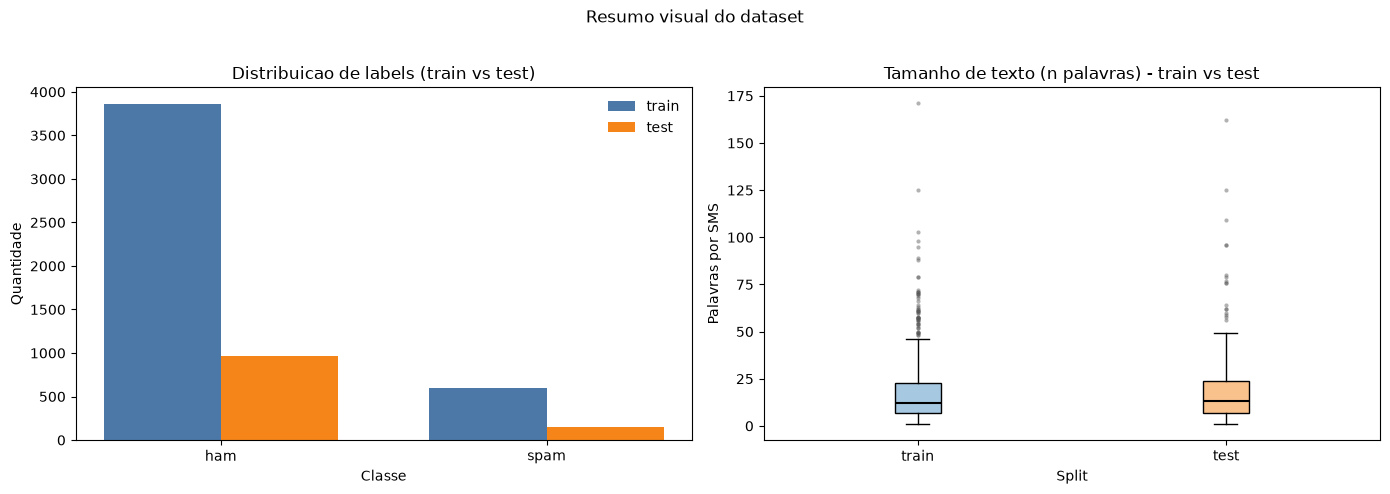

Exemplos de SMS por classe (mensagem completa):


,label,text
0,ham,Old Orchard near univ. How about you?
1,spam,Great NEW Offer - DOUBLE Mins & DOUBLE Txt on best Orange tariffs AND get latest camera phones 4 FREE! Call MobileUpd8 free on 08000839402 NOW! or 2stoptxt T&Cs


In [48]:
try:
    ds = load_dataset("codesignal/sms-spam-collection")
except Exception as e:
    raise RuntimeError(f"Erro ao carregar o dataset 'codesignal/sms-spam-collection': {e}")

raw_df = pd.DataFrame(ds["train"])
print(f"Dataset original (antes do split): {raw_df.shape}")

df_train_raw, df_test_raw = train_test_split(
    raw_df,
    test_size=0.20,
    random_state=42,
    stratify=raw_df["label"],
)
df_train_raw = df_train_raw.reset_index(drop=True)
df_test_raw = df_test_raw.reset_index(drop=True)

def build_sms_df(df_raw):
    df = df_raw[["label", "message"]].copy()
    df = df.rename(columns={"message": "text"})
    df["label"] = df["label"].astype(str).str.strip().str.lower()
    df["target"] = df["label"].map(lambda x: 1 if x == "spam" else 0)
    df["text"] = df["text"].astype(str).str.strip()
    return df[["label", "target", "text"]].reset_index(drop=True)

df_train = build_sms_df(df_train_raw)
df_test = build_sms_df(df_test_raw)

print(f"Tamanho dos splits -> train: {len(df_train)} | test: {len(df_test)}")

print("Primeiras linhas (train):")
display(df_train[["label", "text"]].head(5))

dist_train = (
    df_train["label"]
    .value_counts()
    .reindex(["ham", "spam"], fill_value=0)
)
dist_test = (
    df_test["label"]
    .value_counts()
    .reindex(["ham", "spam"], fill_value=0)
)

dist_df = pd.DataFrame({
    "label": ["ham", "spam"],
    "train_count": dist_train.values,
    "test_count": dist_test.values,
})
dist_df["train_pct"] = (dist_df["train_count"] / len(df_train) * 100).round(2)
dist_df["test_pct"] = (dist_df["test_count"] / len(df_test) * 100).round(2)

sample_train = df_train.sample(n=min(5000, len(df_train)), random_state=42).copy()
sample_test = df_test.sample(n=min(5000, len(df_test)), random_state=42).copy()
sample_train["text_n_words"] = sample_train["text"].str.split().str.len()
sample_test["text_n_words"] = sample_test["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

x = np.arange(len(dist_df))
width = 0.36
bars_train = axes[0].bar(
    x - width / 2,
    dist_df["train_count"],
    width,
    label="train",
    color="#4C78A8",
)
bars_test = axes[0].bar(
    x + width / 2,
    dist_df["test_count"],
    width,
    label="test",
    color="#F58518",
)
axes[0].set_title("Distribuicao de labels (train vs test)")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Quantidade")
axes[0].set_xticks(x)
axes[0].set_xticklabels(dist_df["label"])
axes[0].legend(frameon=False)

bp = axes[1].boxplot(
    [sample_train["text_n_words"].values, sample_test["text_n_words"].values],
    tick_labels=["train", "test"],
    patch_artist=True,
    showfliers=True,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.45, "markerfacecolor": "#555555", "markeredgecolor": "none"},
    medianprops={"color": "black", "linewidth": 1.5},
)
for patch, color in zip(bp["boxes"], ["#A6C8E0", "#F9C28D"]):
    patch.set_facecolor(color)

axes[1].set_title("Tamanho de texto (n palavras) - train vs test")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Palavras por SMS")

fig.suptitle("Resumo visual do dataset", y=1.02)
plt.tight_layout()
plt.show()

examples_df = pd.concat(
    [
        df_train[df_train["label"] == "ham"].sample(n=1, random_state=42),
        df_train[df_train["label"] == "spam"].sample(n=1, random_state=42),
    ],
    ignore_index=True,
).reset_index(drop=True)

print("Exemplos de SMS por classe (mensagem completa):")
pd.set_option("display.max_colwidth", None)
display(examples_df[["label", "text"]])
pd.reset_option("display.max_colwidth")

### Parâmetros e Configuração

In [59]:
gru_static_config = {
    "data": {
        "val_size": 0.15,
        "random_state": 42,
        "clean_text": True,
        "min_freq": 1,
        "max_vocab_size": 5000,
        "special_tokens": ["<pad>", "<unk>"],
        "max_len_percentile": 95,
        "max_len_min": 8,
        "max_len_cap": 60,
        "batch_size": 64,
        "class_weight_power": 0.4,
    },
    "train": {
        "epochs": 12,
        "learning_rate": 1e-3,
        "weight_decay": 3e-5,
        "grad_clip": 1.0,
        "early_stopping_patience": 2,
    },
}

gru_model_configs = [
    {
        "name": "Config A",
        "model": {
            "embedding_dim": 24,
            "hidden_size": 24,
            "num_layers": 1,
            "dropout": 0.0,
            "bidirectional": False,
            "use_class_weights": False,
        },
    },
    {
        "name": "Config B",
        "model": {
            "embedding_dim": 96,
            "hidden_size": 96,
            "num_layers": 2,
            "dropout": 0.3,
            "bidirectional": True,
            "use_class_weights": True,
        },
    },
]

print("\nConfiguração fixa (GRU):\n")
for section_name in ["data", "train"]:
    print(f"[{section_name}]")
    for k, v in gru_static_config[section_name].items():
        print(f"- {k}: {v}")
    print()

model_cfg_by_name = {}
for i, cfg_item in enumerate(gru_model_configs):
    cfg_name = cfg_item.get("name", f"Config {i}")
    model_cfg_by_name[cfg_name] = cfg_item["model"]
gru_model_cfg_df = pd.DataFrame(model_cfg_by_name)

print("Comparação de modelos (GRU):")
display(gru_model_cfg_df)


Configuração fixa (GRU):

[data]
- val_size: 0.15
- random_state: 42
- clean_text: True
- min_freq: 1
- max_vocab_size: 5000
- special_tokens: ['<pad>', '<unk>']
- max_len_percentile: 95
- max_len_min: 8
- max_len_cap: 60
- batch_size: 64
- class_weight_power: 0.4

[train]
- epochs: 12
- learning_rate: 0.001
- weight_decay: 3e-05
- grad_clip: 1.0
- early_stopping_patience: 2

Comparação de modelos (GRU):


,Config A,Config B
embedding_dim,24,96
hidden_size,24,96
num_layers,1,2
dropout,0.0,0.3
bidirectional,False,True
use_class_weights,False,True


### Pré-processamento para GRU

In [102]:
cfg_data = gru_static_config["data"]
df_train_model = df_train[["text", "target"]].copy()
df_test_model = df_test[["text", "target"]].copy()

train_df, val_df = train_test_split(
    df_train_model,
    test_size=cfg_data["val_size"],
    random_state=cfg_data["random_state"],
    stratify=df_train_model["target"],
)
test_df = df_test_model.copy()

def tokenize_sms(text):
    text = str(text).lower()
    if cfg_data.get("clean_text", True):
        text = re.sub(r"[^a-z0-9\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
    return text.split()

counter = Counter()
for txt in train_df["text"]:
    counter.update(tokenize_sms(txt))

min_freq = cfg_data["min_freq"]
max_vocab_size = cfg_data["max_vocab_size"]
special_tokens = cfg_data["special_tokens"]

vocab_tokens = [tok for tok, freq in counter.items() if freq >= min_freq]
vocab_tokens = sorted(vocab_tokens, key=lambda t: counter[t], reverse=True)
vocab_tokens = vocab_tokens[:max_vocab_size - len(special_tokens)]

gru_itos = special_tokens + vocab_tokens
gru_stoi = {tok: idx for idx, tok in enumerate(gru_itos)}

GRU_PAD_IDX = gru_stoi["<pad>"]
GRU_UNK_IDX = gru_stoi["<unk>"]

def encode_sms(text):
    return [gru_stoi.get(tok, GRU_UNK_IDX) for tok in tokenize_sms(text)]

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["seq"] = train_df["text"].map(encode_sms)
val_df["seq"] = val_df["text"].map(encode_sms)
test_df["seq"] = test_df["text"].map(encode_sms)

train_lengths = train_df["seq"].map(len).values
gru_max_len = int(np.percentile(train_lengths, cfg_data["max_len_percentile"]))
gru_max_len = max(cfg_data["max_len_min"], min(gru_max_len, cfg_data["max_len_cap"]))

def pad_or_truncate_sms(seq, max_len, pad_idx=GRU_PAD_IDX):
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [pad_idx] * (max_len - len(seq))

X_train = np.array([pad_or_truncate_sms(s, gru_max_len) for s in train_df["seq"]], dtype=np.int64)
X_val = np.array([pad_or_truncate_sms(s, gru_max_len) for s in val_df["seq"]], dtype=np.int64)
X_test = np.array([pad_or_truncate_sms(s, gru_max_len) for s in test_df["seq"]], dtype=np.int64)

y_train = train_df["target"].to_numpy(dtype=np.int64)
y_val = val_df["target"].to_numpy(dtype=np.int64)
y_test = test_df["target"].to_numpy(dtype=np.int64)

class_counts = np.bincount(y_train, minlength=2).astype(np.float32)
raw_class_weights = class_counts.sum() / np.maximum(class_counts, 1.0)
class_weight_power = float(cfg_data.get("class_weight_power", 1.0))
class_weights = np.power(raw_class_weights, class_weight_power)
class_weights = class_weights / class_weights.mean()
gru_class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)

batch_size = cfg_data["batch_size"]
pin_memory = device.type == "cuda"
loader_kwargs = {"batch_size": batch_size, "pin_memory": pin_memory}

gru_train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.long),
    torch.tensor(y_train, dtype=torch.long),
)
gru_val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.long),
    torch.tensor(y_val, dtype=torch.long),
)
gru_test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.long),
    torch.tensor(y_test, dtype=torch.long),
)

gru_train_loader = DataLoader(gru_train_dataset, shuffle=True, **loader_kwargs)
gru_val_loader = DataLoader(gru_val_dataset, shuffle=False, **loader_kwargs)
gru_test_loader = DataLoader(gru_test_dataset, shuffle=False, **loader_kwargs)

print("Pre-processamento GRU concluido.")
print(f"splits -> train: {len(y_train)}, val: {len(y_val)}, test: {len(y_test)}")
print(f"vocab_size: {len(gru_itos)} | max_len: {gru_max_len} | batch_size: {batch_size}")
print("class_counts (train):", class_counts.astype(int).tolist())
print("class_weight_power:", class_weight_power)
print("class_weights (CrossEntropy):", np.round(class_weights, 4).tolist())

Pre-processamento GRU concluido.
splits -> train: 3788, val: 669, test: 1115
vocab_size: 5000 | max_len: 33 | batch_size: 64
class_counts (train): [3280, 508]
class_weight_power: 0.4
class_weights (CrossEntropy): [0.6434000134468079, 1.356600046157837]


### GRU

In [103]:
num_classes = len(np.unique(np.concatenate([y_train, y_val, y_test])))

class SMSGRUClassifier(nn.Module):
    def __init__(self, vocab_size, pad_idx, model_cfg):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=model_cfg["embedding_dim"],
            padding_idx=pad_idx,
        )

        effective_dropout = model_cfg["dropout"] if model_cfg["num_layers"] > 1 else 0.0

        self.gru = nn.GRU(
            input_size=model_cfg["embedding_dim"],
            hidden_size=model_cfg["hidden_size"],
            num_layers=model_cfg["num_layers"],
            batch_first=True,
            dropout=effective_dropout,
            bidirectional=model_cfg["bidirectional"],
        )

        out_dim = model_cfg["hidden_size"] * (2 if model_cfg["bidirectional"] else 1)
        self.fc = nn.Linear(out_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        _, h_n = self.gru(emb)

        if self.gru.bidirectional:
            h_last = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            h_last = h_n[-1]

        logits = self.fc(h_last)
        return logits

def run_gru_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    grad_clip=None,
    max_batches=None,
):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_examples = 0
    all_preds = []
    all_targets = []

    for batch_idx, (xb, yb) in enumerate(loader):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        batch_size = yb.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(yb.detach().cpu().numpy())

        if max_batches is not None and (batch_idx + 1) >= max_batches:
            break

    avg_loss = total_loss / max(total_examples, 1)
    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, zero_division=0)
    rec = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)

    return {
        "loss": avg_loss,
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }

def train_gru_experiment(static_cfg, model_cfg, verbose=False):
    model = SMSGRUClassifier(
        vocab_size=len(gru_itos),
        pad_idx=GRU_PAD_IDX,
        model_cfg=model_cfg,
    ).to(device)

    use_class_weights = model_cfg.get("use_class_weights", False)
    if use_class_weights:
        criterion = nn.CrossEntropyLoss(weight=gru_class_weights_tensor)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=static_cfg["train"]["learning_rate"],
        weight_decay=static_cfg["train"]["weight_decay"],
    )

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_f1": [], "val_f1": [],
    }

    max_train_batches = static_cfg["train"].get("max_train_batches")
    max_eval_batches = static_cfg["train"].get("max_eval_batches")

    best_val_loss = float("inf")
    best_state = None
    patience = 0

    total_epochs = static_cfg["train"]["epochs"]

    for epoch in range(1, total_epochs + 1):
        train_metrics = run_gru_epoch(
            model,
            gru_train_loader,
            criterion,
            optimizer=optimizer,
            grad_clip=static_cfg["train"]["grad_clip"],
            max_batches=max_train_batches,
        )
        val_metrics = run_gru_epoch(
            model,
            gru_val_loader,
            criterion,
            optimizer=None,
            max_batches=max_eval_batches,
        )

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(train_metrics["acc"])
        history["val_acc"].append(val_metrics["acc"])
        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])

        if verbose:
            print(
                f"Epoch {epoch:02d}/{total_epochs} | "
                f"train_loss={train_metrics['loss']:.4f} val_loss={val_metrics['loss']:.4f} | "
                f"train_acc={train_metrics['acc']:.4f} val_acc={val_metrics['acc']:.4f} | "
                f"val_f1={val_metrics['f1']:.4f}"
            )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= static_cfg["train"]["early_stopping_patience"]:
                if verbose:
                    print("Early stopping acionado.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = run_gru_epoch(
        model,
        gru_test_loader,
        criterion,
        optimizer=None,
        max_batches=max_eval_batches,
    )

    all_preds = []
    all_targets = []
    model.eval()
    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(gru_test_loader):
            xb = xb.to(device, non_blocking=True)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(yb.numpy())

            if max_eval_batches is not None and (batch_idx + 1) >= max_eval_batches:
                break

    cm = confusion_matrix(all_targets, all_preds)
    cm_df = pd.DataFrame(cm, index=["Real ham (0)", "Real spam (1)"], columns=["Pred ham (0)", "Pred spam (1)"])

    return {
        "model": model,
        "history": history,
        "test_metrics": test_metrics,
        "confusion_matrix": cm,
        "confusion_matrix_df": cm_df,
        "used_static_cfg": static_cfg,
        "used_model_cfg": model_cfg,
        "used_class_weights": use_class_weights,
    }

### Rodando os Experimentos

In [106]:
gru_experiment_runs = {}
for i, cfg_item in enumerate(gru_model_configs):
    cfg_name = cfg_item.get("name", f"Config {i}")
    gru_experiment_runs[cfg_name] = train_gru_experiment(
        static_cfg=gru_static_config,
        model_cfg=cfg_item["model"],
        verbose=False,
    )

### Resultados

Metricas:


config,loss,accuracy,precision,recall,f1
Config A,0.095666,0.973094,0.904762,0.892617,0.898649
Config B,0.112167,0.965919,0.844720,0.912752,0.877419



Matrizes de confusão (uma por config):

Config A


,Pred ham (0),Pred spam (1)
Real ham (0),952,14
Real spam (1),16,133



Config B


,Pred ham (0),Pred spam (1)
Real ham (0),941,25
Real spam (1),13,136


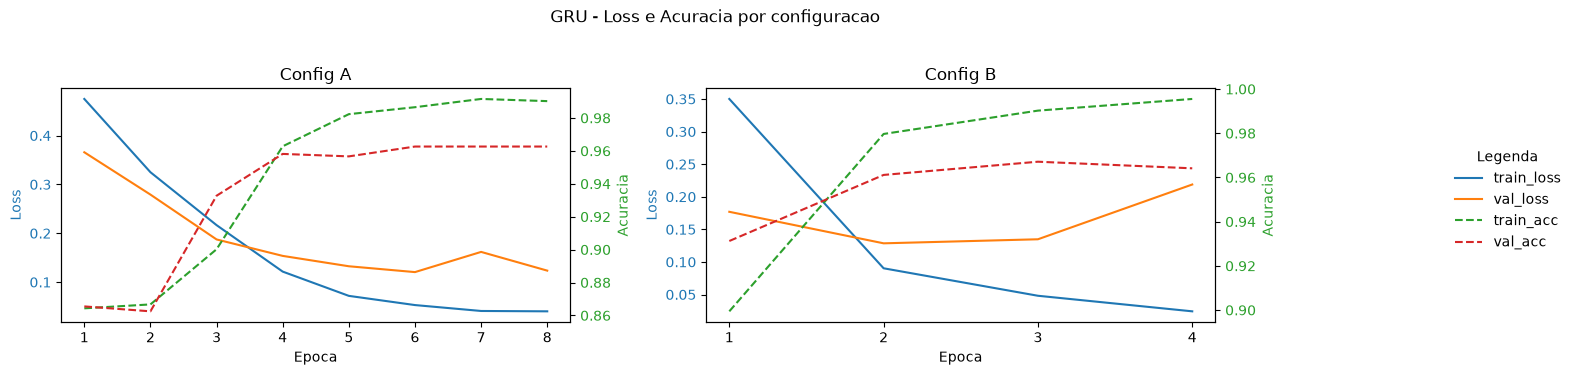

In [108]:
rows = []
for cfg_name, run in gru_experiment_runs.items():
    tm = run["test_metrics"]
    rows.append({
        "config": cfg_name,
        "loss": tm["loss"],
        "accuracy": tm["acc"],
        "precision": tm["precision"],
        "recall": tm["recall"],
        "f1": tm["f1"],
    })
gru_metrics_df = pd.DataFrame(rows)

print("Metricas:")
display(gru_metrics_df.style.hide(axis="index"))

print("\nMatrizes de confusão (uma por config):")
for cfg_name, run in gru_experiment_runs.items():
    print(f"\n{cfg_name}")
    display(run["confusion_matrix_df"])

cfg_names = list(gru_experiment_runs.keys())
n_cfg = len(cfg_names)
fig, axes = plt.subplots(1, n_cfg, figsize=(7.2 * n_cfg, 3.6), squeeze=False)
axes = axes[0]

legend_handles = None
legend_labels = None

for i, cfg_name in enumerate(cfg_names):
    run = gru_experiment_runs[cfg_name]
    history = run["history"]
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    ax1 = axes[i]
    ln1 = ax1.plot(epochs, history["train_loss"], label="train_loss", color="tab:blue")
    ln2 = ax1.plot(epochs, history["val_loss"], label="val_loss", color="tab:orange")
    ax1.set_xlabel("Epoca")
    ax1.set_ylabel("Loss", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.set_xticks(epochs)

    ax2 = ax1.twinx()
    ln3 = ax2.plot(epochs, history["train_acc"], label="train_acc", color="tab:green", linestyle="--")
    ln4 = ax2.plot(epochs, history["val_acc"], label="val_acc", color="tab:red", linestyle="--")
    ax2.set_ylabel("Acuracia", color="tab:green")
    ax2.tick_params(axis="y", labelcolor="tab:green")

    if legend_handles is None:
        legend_handles = ln1 + ln2 + ln3 + ln4
        legend_labels = [l.get_label() for l in legend_handles]

    ax1.set_title(cfg_name)

fig.suptitle("GRU - Loss e Acuracia por configuracao", y=1.03)
fig.legend(
    legend_handles,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(1.005, 0.5),
    frameon=False,
    title="Legenda",
)

plt.tight_layout(rect=(0, 0, 0.9, 1))
plt.show()

### Análise & Discussão

O problema em questão é de classificação supervisionada de sequências. Recebemos uma entrada em texto e o objetivo é classificar se a mensagem é spam ou ham. Como só existem dois rótulos possíveis, trata-se de classificação binária. Mesmo com mensagens curtas, ainda é uma tarefa sequencial, porque a ordem das palavras importa e existe dependência contextual entre os termos para formar o sentido da mensagem. Isso é importante porque, em NLP, trocar a ordem ou remover uma parte da sequência pode mudar totalmente a interpretação.

Comparando com a Questão 2, aqui as entradas são consideravelmente menores e o dataset também é bem menor (menos de 6k amostras, contra ~50k no IMDb). Isso explica a escolha da GRU  para esse problema, já que ela é uma arquitetura recorrente mais enxuta, com menor custo computacional, menos parâmetros e treino mais rápido, sem perder a capacidade de modelar dependências úteis para SMS. Em mensagens curtas, os padrões costumam ser mais diretos (links, urgência, promoções, números, gatilhos de spam), enquanto textos longos dependem mais de contexto amplo e relações distantes ao longo da sequência, o que geralmente favorece arquiteturas mais pesadas como LSTM.

Também existe desbalanceamento de classes e isso aparece desde a exploração inicial: a classe ham é majoritária (acima de 85%). Esse cenário é perigoso porque o modelo pode “aprender a acertar por maioria”, ficando enviesado para a classe dominante. Para mitigar isso, na Config B foi usada penalização por classe (class weights), enquanto na Config A não. A ideia foi justamente comparar duas estratégias com complexidade diferente e observar o impacto desse ajuste nas métricas. Em termos qualitativos, a Config A deveria representar um baseline mais simples e conservador; a Config B deveria representar um modelo mais robusto, com maior capacidade de representação e com viés intencional para reduzir erro na classe minoritária.

Sobre quais métricas são mais importantes em spam detection: acurácia sozinha não basta, principalmente com base desbalanceada. As métricas mais úteis aqui são recall da classe spam, F1 e matriz de confusão. O recall mostra quanto spam real o modelo consegue capturar; o F1 resume o equilíbrio entre precisão e recall; e a matriz de confusão permite enxergar exatamente onde o modelo está errando, com a diagonal principal representando os acertos. Em classificação binária, essa interpretação (especialmente na matriz de confusão) é mais direta, porque podemos ver claramente falsos positivos e falsos negativos.

Os falsos positivos e falsos negativos impactam muito. Em uma base desbalanceada, esses erros precisam ser lidos com cuidado, porque o modelo pode parecer bom em acurácia e ainda assim performar mal no que mais importa para o problema.

Nos resultados obtidos, as duas redes performaram bem, mas com trade-off claro. A Config A foi melhor no conjunto geral (loss, accuracy, precision e F1), enquanto a Config B teve recall maior para spam, o que era esperado pelo uso de pesos de classe e pela proposta de reduzir erro na classe minoritária. Em outras palavras, a A é mais conservadora e a B é mais agressiva para detectar spam. Isso aparece na matriz de confusão: a B reduz falsos negativos, mas aumenta falsos positivos. Outro sinal do viés para spam é que a B previu spam mais vezes do que a A (diferença de 14 previsões).

Quanto a overfitting, há sinais de tendência de sobreajuste nas curvas, especialmente porque o train_loss cai bastante, o val_loss oscila e a acurácia nos treinos fica muito próxima de 1 em ambas as configs. Ao mesmo tempo, não é um cenário de overfitting severo, já que o early stopping interrompeu o treino antes de degradar mais (na Config B ele acionou antes, com 4 épocas a menos que a A) e o desempenho em teste continuou estável. Resumidamente, existe indício de overfitting controlado, mas a rede continua generalizando bem para o conjunto de validação.

Por fim, a semelhança de desempenho entre as duas configurações também faz sentido dado o tamanho e o tipo do dataset. Em base pequena, com mensagens curtas e padrões relativamente diretos, modelos menores e configs mais simples podem competir bem. Isso reforça o trade-off: aumentar complexidade e penalização de classe pode melhorar a captura de spam, mas nem sempre melhora todas as métricas ao mesmo tempo. Em resumo, a escolha da configuração final da rede depende do que se deseja atingir. Se o foco principal for reduzir spam que passa despercebido, a Config B faz mais sentido; se o foco for equilíbrio geral com menos alarmes falsos, a Config A é a escolha.

## Questão 4: Transformer - SST-2

### Exploração e Entendimento Inicial do Dataset

DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})

Overview geral:
- colunas: ['idx', 'sentence', 'label']
- tamanho train: (67349, 3) | tamanho validation: (872, 3) | tamanho test: (1821, 3)

Primeiras linhas (train):


,sentiment,text
0,negative,hide new secretions from the parental units
1,negative,"contains no wit , only labored gags"
2,positive,that loves its characters and communicates som...
3,negative,remains utterly satisfied to remain the same t...
4,negative,on the worst revenge-of-the-nerds clichés the ...


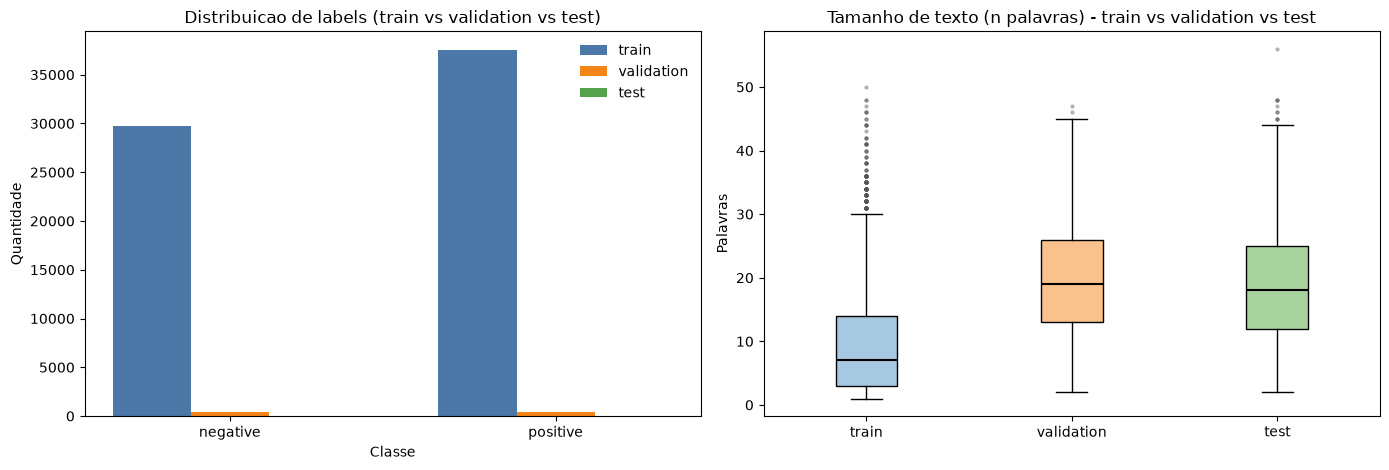

In [48]:
ds = load_dataset("stanfordnlp/sst2")

print(ds)

df_train_raw = pd.DataFrame(ds["train"])
df_val_raw = pd.DataFrame(ds["validation"])
df_test_raw = pd.DataFrame(ds["test"])

print("\nOverview geral:")
print("- colunas:", list(df_train_raw.columns))
print(
    f"- tamanho train: {df_train_raw.shape} | tamanho validation: {df_val_raw.shape} | tamanho test: {df_test_raw.shape}"
)

def detect_text_column(df_raw):
    text_candidates = ["sentence", "text", "review", "content"]
    for col in text_candidates:
        if col in df_raw.columns:
            return col

    object_cols = [c for c in df_raw.columns if df_raw[c].dtype == "object"]
    if object_cols:
        return object_cols[0]

    raise ValueError("Nao foi possivel identificar a coluna de texto do SST-2.")

text_col = detect_text_column(df_train_raw)
for split_name, df_split in [("validation", df_val_raw), ("test", df_test_raw)]:
    if text_col not in df_split.columns:
        raise ValueError(f"Coluna de texto '{text_col}' nao encontrada no split de {split_name}.")

for split_name, df_split in [("train", df_train_raw), ("validation", df_val_raw), ("test", df_test_raw)]:
    if "label" not in df_split.columns:
        raise ValueError(f"Dataset nao possui a coluna 'label' em {split_name}.")

sst2_label_map = {0: "negative", 1: "positive"}

def build_sst2_df(df_raw):
    df = df_raw[["label", text_col]].copy()
    df = df.rename(columns={text_col: "text"})
    df["label"] = df["label"].astype(int)
    df["text"] = df["text"].astype(str).str.strip()
    df["sentiment"] = df["label"].map(sst2_label_map)
    return df[["label", "sentiment", "text"]].reset_index(drop=True)

df_train = build_sst2_df(df_train_raw)
df_val = build_sst2_df(df_val_raw)
df_test = build_sst2_df(df_test_raw)

print("\nPrimeiras linhas (train):")
display(df_train[["sentiment", "text"]].head(5))

train_counts = df_train["sentiment"].value_counts().reindex(["negative", "positive"], fill_value=0)
val_counts = df_val["sentiment"].value_counts().reindex(["negative", "positive"], fill_value=0)
test_counts = df_test["sentiment"].value_counts().reindex(["negative", "positive"], fill_value=0)

dist_df = pd.DataFrame({
    "sentiment": ["negative", "positive"],
    "train_count": train_counts.values,
    "validation_count": val_counts.values,
    "test_count": test_counts.values,
})
dist_df["train_pct"] = (dist_df["train_count"] / len(df_train) * 100).round(2)
dist_df["validation_pct"] = (dist_df["validation_count"] / len(df_val) * 100).round(2)
dist_df["test_pct"] = (dist_df["test_count"] / len(df_test) * 100).round(2)

sample_train = df_train.sample(n=min(5000, len(df_train)), random_state=42).copy()
sample_val = df_val.sample(n=min(5000, len(df_val)), random_state=42).copy()
sample_test = df_test.sample(n=min(5000, len(df_test)), random_state=42).copy()
sample_train["text_n_words"] = sample_train["text"].str.split().str.len()
sample_val["text_n_words"] = sample_val["text"].str.split().str.len()
sample_test["text_n_words"] = sample_test["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

x = np.arange(len(dist_df))
width = 0.24
axes[0].bar(x - width, dist_df["train_count"], width, label="train", color="#4C78A8")
axes[0].bar(x, dist_df["validation_count"], width, label="validation", color="#F58518")
axes[0].bar(x + width, dist_df["test_count"], width, label="test", color="#54A24B")
axes[0].set_title("Distribuicao de labels (train vs validation vs test)")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Quantidade")
axes[0].set_xticks(x)
axes[0].set_xticklabels(dist_df["sentiment"])
axes[0].legend(frameon=False)

bp = axes[1].boxplot(
    [sample_train["text_n_words"].values, sample_val["text_n_words"].values, sample_test["text_n_words"].values],
    tick_labels=["train", "validation", "test"],
    patch_artist=True,
    showfliers=True,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.45, "markerfacecolor": "#555555", "markeredgecolor": "none"},
    medianprops={"color": "black", "linewidth": 1.5},
)
for patch, color in zip(bp["boxes"], ["#A6C8E0", "#F9C28D", "#A9D39E"]):
    patch.set_facecolor(color)

axes[1].set_title("Tamanho de texto (n palavras) - train vs validation vs test")
axes[1].set_ylabel("Palavras")
plt.tight_layout()
plt.show()


### Parâmetros e Configuração

In [57]:
sst2_static_config = {
    "data": {
        "label_col": "label",
        "text_col": "text",
        "model_name": "distilbert-base-uncased",
        "max_len_percentile": 95,
        "max_len_min": 16,
        "max_len_cap": 64,
        "batch_size": 32,
        "train_sample_size": 8192,
        "prediction_sample_size": 64,
    },
    "train": {
        "epochs": 6,
        "weight_decay": 0.01,
        "grad_clip": 1.0,
        "early_stopping_patience": 2,
        "warmup_ratio": 0.1,
        "max_train_batches": None,
    },
}

sst2_model_configs = [
    {
        "name": "Config A - Extracao de representacoes",
        "model": {
            "model_name": "distilbert-base-uncased",
            "freeze_encoder": True,
            "learning_rate": 5e-4,
        },
    },
    {
        "name": "Config B - Fine-tuning completo",
        "model": {
            "model_name": "distilbert-base-uncased",
            "freeze_encoder": False,
            "learning_rate": 2e-5,
        },
    },
]

print("\nConfiguração fixa (Transformer):\n")
for section_name in ["data", "train"]:
    print(f"[{section_name}]")
    for k, v in sst2_static_config[section_name].items():
        print(f"- {k}: {v}")
    print()

model_cfg_by_name = {}
for i, cfg_item in enumerate(sst2_model_configs):
    cfg_name = cfg_item.get("name", f"Config {i}")
    model_cfg_by_name[cfg_name] = cfg_item["model"]
sst2_model_cfg_df = pd.DataFrame(model_cfg_by_name)

print("Comparação de modelos (Transformer):")
display(sst2_model_cfg_df)



Configuração fixa (Transformer):

[data]
- label_col: label
- text_col: text
- model_name: distilbert-base-uncased
- max_len_percentile: 95
- max_len_min: 16
- max_len_cap: 64
- batch_size: 32
- train_sample_size: 8192
- prediction_sample_size: 64

[train]
- epochs: 6
- weight_decay: 0.01
- grad_clip: 1.0
- early_stopping_patience: 2
- warmup_ratio: 0.1
- max_train_batches: None

Comparação de modelos (Transformer):


,Config A - Extracao de representacoes,Config B - Fine-tuning completo
model_name,distilbert-base-uncased,distilbert-base-uncased
freeze_encoder,True,False
learning_rate,0.0005,0.00002


### Pré-processamento para Transformer

In [64]:
cfg_data = sst2_static_config["data"]
label_col = cfg_data["label_col"]
text_col = cfg_data["text_col"]

df_train_model = df_train[[label_col, text_col]].copy()
df_val_model = df_val[[label_col, text_col]].copy()
df_test_model = df_test[[label_col, text_col]].copy()

train_sample_size = cfg_data.get("train_sample_size")
if train_sample_size is not None and train_sample_size < len(df_train_model):
    train_df, _ = train_test_split(
        df_train_model,
        train_size=train_sample_size,
        random_state=42,
        stratify=df_train_model[label_col],
    )
    train_df = train_df.reset_index(drop=True)
else:
    train_df = df_train_model.copy()

val_df = df_val_model.copy()

prediction_sample_size = cfg_data.get("prediction_sample_size")
if prediction_sample_size is not None and prediction_sample_size < len(df_test_model):
    test_df = df_test_model.sample(n=prediction_sample_size, random_state=42).reset_index(drop=True)
else:
    test_df = df_test_model.copy()

print(f"Train usado no experimento: {train_df.shape} | validation oficial: {val_df.shape} | test para inferencia: {test_df.shape}")

sst2_tokenizer = AutoTokenizer.from_pretrained(cfg_data["model_name"])

train_lengths = train_df[text_col].astype(str).map(lambda x: len(sst2_tokenizer.tokenize(x))).values
sst2_max_len = int(np.percentile(train_lengths, cfg_data["max_len_percentile"]))
sst2_max_len = max(cfg_data["max_len_min"], min(sst2_max_len, cfg_data["max_len_cap"]))

print(f"Comprimento maximo escolhido: {sst2_max_len} tokens")
print(pd.Series(train_lengths).describe())

class SST2TextDataset(Dataset):
    def __init__(self, df, tokenizer, text_col, label_col, max_len):
        enc = tokenizer(
            df[text_col].astype(str).tolist(),
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_tensors="pt",
        )
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels = torch.tensor(df[label_col].to_numpy(dtype=np.int64), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx],
        }

sst2_train_dataset = SST2TextDataset(train_df, sst2_tokenizer, text_col, label_col, sst2_max_len)
sst2_val_dataset = SST2TextDataset(val_df, sst2_tokenizer, text_col, label_col, sst2_max_len)
sst2_test_dataset = SST2TextDataset(test_df, sst2_tokenizer, text_col, label_col, sst2_max_len)

batch_size = cfg_data["batch_size"]
pin_memory = device.type == "cuda"

sst2_train_loader = DataLoader(sst2_train_dataset, batch_size=batch_size, shuffle=True, pin_memory=pin_memory)
sst2_val_loader = DataLoader(sst2_val_dataset, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)
sst2_test_loader = DataLoader(sst2_test_dataset, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)

Train usado no experimento: (8192, 2) | validation oficial: (872, 2) | test para inferencia: (64, 2)
Comprimento maximo escolhido: 31 tokens
count    8192.000000
mean       11.239624
std         9.560432
min         1.000000
25%         4.000000
50%         8.000000
75%        15.000000
max        64.000000
dtype: float64


### Transformer

In [ ]:
num_classes = len(np.unique(np.concatenate([
    df_train_model[label_col].values,
    df_val_model[label_col].values,
])))

class SST2DistilBERTClassifier(nn.Module):
    def __init__(self, model_name, freeze_encoder=False):
        super().__init__()
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_classes)
        if freeze_encoder:
            for param in self.model.distilbert.parameters():
                param.requires_grad = False

    def forward(self, input_ids, attention_mask, labels=None):
        return self.model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

def run_transformer_epoch(model, loader, criterion=None, optimizer=None, scheduler=None, grad_clip=None, max_batches=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_examples = 0
    all_preds = []
    all_targets = []

    for batch_idx, batch in enumerate(loader):
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            if is_train:
                loss.backward()
                if grad_clip is not None:
                    nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(labels.detach().cpu().numpy())

        if max_batches is not None and (batch_idx + 1) >= max_batches:
            break

    avg_loss = total_loss / max(total_examples, 1)
    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, zero_division=0)
    rec = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)

    return {
        "loss": avg_loss,
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "preds": np.array(all_preds),
        "targets": np.array(all_targets),
    }

def train_transformer_experiment(static_cfg, model_cfg, verbose=False):
    model = SST2DistilBERTClassifier(
        model_name=model_cfg["model_name"],
        freeze_encoder=model_cfg["freeze_encoder"],
    ).to(device)

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(
        trainable_params,
        lr=model_cfg["learning_rate"],
        weight_decay=static_cfg["train"]["weight_decay"],
    )

    max_train_batches = static_cfg["train"].get("max_train_batches")
    train_steps_per_epoch = len(sst2_train_loader)
    if max_train_batches is not None:
        train_steps_per_epoch = min(train_steps_per_epoch, int(max_train_batches))

    total_steps = max(1, train_steps_per_epoch * static_cfg["train"]["epochs"])
    warmup_steps = max(1, int(total_steps * static_cfg["train"]["warmup_ratio"]))
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_state = None
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(static_cfg["train"]["epochs"]):
        train_metrics = run_transformer_epoch(
            model,
            sst2_train_loader,
            optimizer=optimizer,
            scheduler=scheduler,
            grad_clip=static_cfg["train"]["grad_clip"],
            max_batches=max_train_batches,
        )
        val_metrics = run_transformer_epoch(model, sst2_val_loader)

        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["acc"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["acc"])

        if verbose:
            print(
                f"Epoch {epoch + 1:02d} | train_loss={train_metrics['loss']:.4f} | train_acc={train_metrics['acc']:.4f} | "
                f"val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['acc']:.4f}"
            )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= static_cfg["train"]["early_stopping_patience"]:
                if verbose:
                    print(f"Early stopping na epoca {epoch + 1}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    final_metrics = run_transformer_epoch(model, sst2_val_loader)
    cm = confusion_matrix(final_metrics["targets"], final_metrics["preds"])
    cm_df = pd.DataFrame(cm, index=["true_negative", "true_positive"], columns=["pred_negative", "pred_positive"])

    prediction_rows = []
    model.eval()
    with torch.no_grad():
        for batch_idx, batch in enumerate(sst2_test_loader):
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            preds = torch.argmax(logits, dim=1).cpu().numpy().tolist()

            start_idx = batch_idx * sst2_test_loader.batch_size
            end_idx = start_idx + len(preds)
            batch_texts = test_df.iloc[start_idx:end_idx][text_col].tolist()
            prediction_rows.extend(list(zip(batch_texts, preds)))

    prediction_preview_df = pd.DataFrame(prediction_rows, columns=[text_col, "pred_label"])
    prediction_preview_df["pred_sentiment"] = prediction_preview_df["pred_label"].map({0: "negative", 1: "positive"})

    return {
        "model": model,
        "history": history,
        "final_metrics": final_metrics,
        "confusion_matrix_df": cm_df,
        "prediction_preview_df": prediction_preview_df,
    }

### Rodando os Experimentos

In [ ]:
sst2_experiment_runs = {}
for i, cfg_item in enumerate(sst2_model_configs):
    cfg_name = cfg_item.get("name", f"Config {i}")
    print(f"\nRodando {cfg_name}...")
    sst2_experiment_runs[cfg_name] = train_transformer_experiment(
        static_cfg=sst2_static_config,
        model_cfg=cfg_item["model"],
        verbose=True,
    )

### Resultados

Metricas:


config,loss,accuracy,precision,recall,f1
Config A - Extracao de representacoes,0.379012,0.826835,0.851319,0.799550,0.824623
Config B - Fine-tuning completo,0.308469,0.870413,0.898795,0.840090,0.868452



Matrizes de confusão (uma por config):

Config A - Extracao de representacoes


,pred_negative,pred_positive
true_negative,366,62
true_positive,89,355



Config B - Fine-tuning completo


,pred_negative,pred_positive
true_negative,386,42
true_positive,71,373


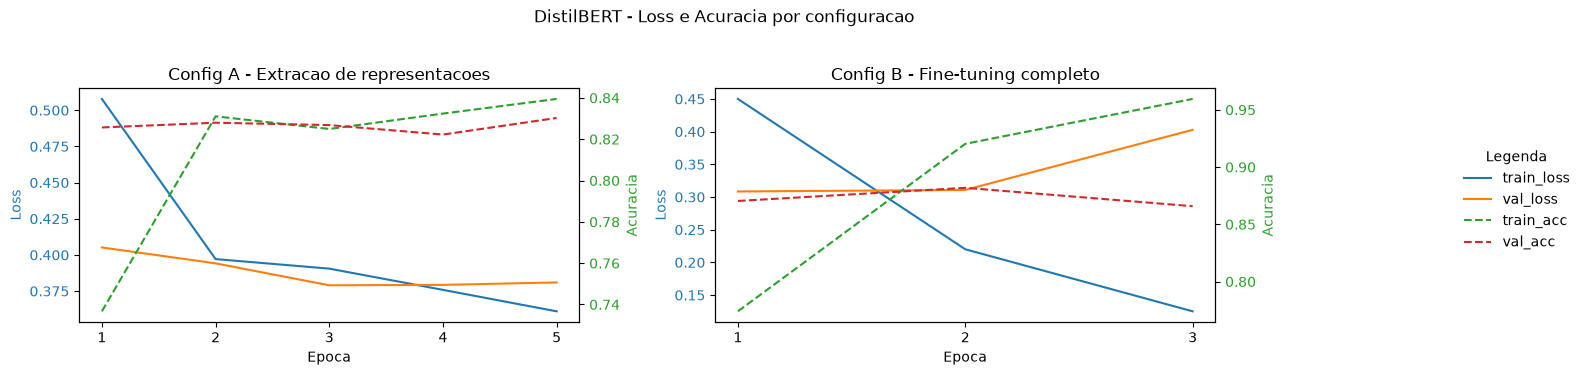

In [68]:
rows = []
for cfg_name, run in sst2_experiment_runs.items():
    tm = run["final_metrics"]
    rows.append({
        "config": cfg_name,
        "loss": tm["loss"],
        "accuracy": tm["acc"],
        "precision": tm["precision"],
        "recall": tm["recall"],
        "f1": tm["f1"],
    })
sst2_metrics_df = pd.DataFrame(rows)

print("Metricas:")
display(sst2_metrics_df.style.hide(axis="index"))

print("\nMatrizes de confusão (uma por config):")
for cfg_name, run in sst2_experiment_runs.items():
    print(f"\n{cfg_name}")
    display(run["confusion_matrix_df"])

cfg_names = list(sst2_experiment_runs.keys())
n_cfg = len(cfg_names)
fig, axes = plt.subplots(1, n_cfg, figsize=(7.2 * n_cfg, 3.6), squeeze=False)
axes = axes[0]

legend_handles = None
legend_labels = None

for i, cfg_name in enumerate(cfg_names):
    run = sst2_experiment_runs[cfg_name]
    history = run["history"]
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    ax1 = axes[i]
    ln1 = ax1.plot(epochs, history["train_loss"], label="train_loss", color="tab:blue")
    ln2 = ax1.plot(epochs, history["val_loss"], label="val_loss", color="tab:orange")
    ax1.set_xlabel("Epoca")
    ax1.set_ylabel("Loss", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.set_xticks(epochs)

    ax2 = ax1.twinx()
    ln3 = ax2.plot(epochs, history["train_acc"], label="train_acc", color="tab:green", linestyle="--")
    ln4 = ax2.plot(epochs, history["val_acc"], label="val_acc", color="tab:red", linestyle="--")
    ax2.set_ylabel("Acuracia", color="tab:green")
    ax2.tick_params(axis="y", labelcolor="tab:green")

    if legend_handles is None:
        legend_handles = ln1 + ln2 + ln3 + ln4
        legend_labels = [l.get_label() for l in legend_handles]

    ax1.set_title(cfg_name)

fig.suptitle("DistilBERT - Loss e Acuracia por configuracao", y=1.03)
fig.legend(
    legend_handles,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(1.005, 0.5),
    frameon=False,
    title="Legenda",
)

plt.tight_layout(rect=(0, 0, 0.9, 1))
plt.show()


### Análise & Discussão

Este problema trata de classificação binária de sentimento em frases curtas do SST-2, onde o objetivo é prever se uma sentença expressa sentimento positivo ou negativo. Diferente das três questões anteriores, aqui o texto não passa por um vocabulário construído manualmente nem por uma conversão simples de palavras para índices. O tokenizer do próprio modelo pré-treinado é responsável por essa etapa, e ele opera por subpalavras.

A tokenização por subpalavras funciona quebrando palavras em partes menores quando necessário. Por exemplo, "running" pode virar `["run", "##ning"]`, e uma palavra rara ou com flexão diferente continua representável porque o modelo reconhece fragmentos menores dela. Nas questões anteriores com RNN, LSTM e GRU, palavras fora do vocabulário construído manualmente simplesmente não existiam para o modelo. Aqui esse problema praticamente desaparece, porque o vocabulário do DistilBERT foi construído em larga escala durante o pré-treino.

Outro ponto diferente é o uso de `attention_mask`. Em modelos recorrentes, o padding entra na sequência e é processado como qualquer outro token. No Transformer isso seria um problema, porque o mecanismo de atenção olha para todas as posições da sequência ao mesmo tempo. Se uma posição de padding influenciasse a atenção, o modelo estaria prestando atenção em informação artificial. A `attention_mask` resolve isso indicando 1 para tokens reais e 0 para padding, de forma que essas posições são ignoradas durante o cálculo da atenção.

Truncar uma sequência significa cortá-la quando ela ultrapassa o comprimento máximo definido. Se uma frase tem 80 tokens e o limite é 32, os 48 tokens excedentes são removidos. Isso é necessário porque o modelo tem um limite físico de comprimento que pode processar, e porque sequências mais longas aumentam o custo computacional de forma quadrática no mecanismo de atenção.

No geral, a preparação para o DistilBERT é mais automatizada do que nos modelos recorrentes. Nas questões anteriores, o vocabulário foi construído do zero, o mapeamento de palavras para índices foi definido manualmente e cada etapa de padding e truncamento foi implementada explicitamente. Aqui, o tokenizer já faz tudo isso em uma única chamada, gerando os `input_ids`, a `attention_mask` e o padding no formato esperado pelo modelo. A diferença conceitual mais importante é que as representações partem de um modelo que já viu milhões de textos, o vocabulário e os embeddings não são aprendidos do zero nesta tarefa.

Para o experimento, foram implementadas as duas abordagens pedidas no enunciado, com o objetivo de comparar diretamente o impacto de cada estratégia. A Config A representa extração de representações, o encoder do DistilBERT fica congelado e apenas a cabeça de classificação é treinada. A Config B representa fine-tuning completo, todos os pesos do modelo, incluindo o encoder, são ajustados durante o treino.

Os resultados confirmaram o que se esperava. A Config B foi superior em todas as métricas: acurácia de 87,0% contra 82,7% da Config A, e F1 de 0.868 contra 0.825. Nas curvas de treino, a Config A converge mais lentamente e estabiliza mais cedo, o que faz sentido porque o encoder não aprende e só a cabeça tenta separar as representações fixas geradas pelo pré-treino. A Config B apresenta queda mais rápida na train_loss com estabilização da val_loss, e o early stopping ativou na época 4, indicando que o modelo começava a se ajustar demais aos dados de treino. Mesmo assim, o desempenho em validação continuou sólido.

A principal vantagem do modelo pré-treinado ficou clara nesse experimento. Mesmo usando apenas 8192 exemplos de treino, o DistilBERT chegou a 87% de acurácia. Uma GRU ou LSTM treinada do zero com o mesmo volume de dados provavelmente não chegaria a esse resultado, porque partiria sem nenhum conhecimento linguístico prévio. O pré-treino funciona como um atalho, o modelo já entende estruturas de linguagem, relações semânticas e contexto, e precisa apenas de um ajuste fino para a tarefa.

O custo computacional, por outro lado, é significativamente maior do que nas questões anteriores. Mesmo com amostragem reduzida e poucas épocas, cada rodada de treino levou bem mais tempo do que a questão com GRU, e tempo similar a questão com LSTM, entretanto usando menos dados (50k no caso da LSTM). Em casos reais, isso se traduz em maior tempo de inferência, mais memória e maior custo.

Para o SST-2 com frases curtas e padrões de sentimento relativamente diretos, uma GRU com bom pré-processamento provavelmente chegaria a um resultado próximo com custo muito menor. O DistilBERT se justifica aqui principalmente pelo pré-treino, visto que ele já chega com representações ricas que compensam o volume reduzido de dados. Em resumo, Transformers tendem a ser mais vantajosos quando há poucos dados, quando o texto é linguisticamente rico e quando a tarefa se beneficia de contexto semântico amplo, e menos justificáveis quando o problema é simples, o padrão no texto é direto ou os recursos computacionais são limitados, visto que nessas situações modelos mais simples podem (e devem) ser suficientes.


## Questão 5: Escolha de arquitetura para dados sequenciais em Ciência de Dados

### a) Comparação entre arquiteturas

| Arquitetura | Base utilizada      | Tipo de dado       | Tarefa principal                    | Força principal                                                                          | Limitação principal                                                                                                 |
| ----------- | ------------------- | ------------------ | ----------------------------------- | ---------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------- |
| RNN simples | AG News             | Texto jornalístico | Classificação multiclasse           | Captura dependências temporais em dados sequenciais.                                     | Dificuldade em modelar dependências longas devido ao desaparecimento do gradiente.                                  |
| LSTM        | IMDb                | Reviews longas     | Classificação binária de sentimento | Modela dependências temporais longas por meio de portas de controle e célula de memória. | Maior custo computacional e maior número de parâmetros.                                                             |
| GRU         | SMS Spam Collection | Mensagens curtas   | Detecção de spam                    | Bom equilíbrio entre desempenho e custo computacional, com menos parâmetros que a LSTM.  | Pode apresentar menor capacidade de modelagem em tarefas muito complexas ou com dependências muito longas.          |
| DistilBERT  | SST-2               | Sentenças curtas   | Classificação binária de sentimento | Captura relações contextuais complexas utilizando conhecimento pré-treinado.             | Alto custo computacional quando comparado às arquiteturas recorrentes, apesar de ser mais leve que o BERT original. |

#### Discussão

#### RNN simples

A principal contribuição da RNN simples foi introduzir a capacidade de modelar dependências temporais em dados sequenciais, permitindo trabalhar com tarefas envolvendo texto, áudio, vídeo e outras sequências. Apesar de atualmente ser pouco utilizada em aplicações práticas de Processamento de Linguagem Natural, ela foi fundamental para o desenvolvimento das arquiteturas recorrentes mais modernas, como LSTM e GRU. Sua principal limitação é a dificuldade em aprender dependências de longo prazo devido ao problema do desaparecimento do gradiente, o que reduz sua capacidade de capturar relações distantes ao longo da sequência.

---

#### LSTM

A LSTM surgiu como uma evolução das RNNs tradicionais ao introduzir portas de controle e uma célula de memória responsável por armazenar informações relevantes ao longo da sequência. Essa arquitetura permite modelar dependências temporais mais longas e reduzir significativamente o impacto do desaparecimento do gradiente, tornando-a bastante adequada para tarefas envolvendo textos longos, como classificação de reviews. Como contrapartida, sua arquitetura possui maior número de parâmetros e maior custo computacional em relação à GRU, além de ser mais simples arquiteturalmente do que os modelos baseados em Transformer.

---

#### GRU

A GRU simplifica a arquitetura da LSTM ao reduzir o número de portas e eliminar a necessidade de uma célula de memória separada. Como consequência, possui menos parâmetros e menor custo computacional, mantendo desempenho semelhante ao da LSTM em diversas aplicações práticas. Essa característica faz da GRU uma excelente alternativa para problemas envolvendo sequências menores, como mensagens SMS, em que o ganho de desempenho da LSTM nem sempre compensa seu maior custo computacional. Entretanto, por possuir uma arquitetura mais simples, pode apresentar menor capacidade de modelagem em tarefas muito complexas ou que exigem capturar dependências extremamente longas.

---

#### DistilBERT

O DistilBERT é uma versão destilada do BERT baseada na arquitetura Transformer. Sua principal vantagem é aproveitar conhecimento obtido durante o pré-treinamento, permitindo capturar relações contextuais complexas entre palavras utilizando mecanismos de atenção. Além disso, seu processamento é altamente paralelizável, diferentemente das arquiteturas recorrentes. Em geral, apresenta desempenho superior em diversas tarefas de Processamento de Linguagem Natural, especialmente quando há disponibilidade de modelos pré-treinados. Como limitação, continua sendo significativamente mais custoso computacionalmente do que RNN, LSTM e GRU, tanto em treinamento quanto em inferência, embora seja consideravelmente mais leve que o BERT original.

---

### b) Comparação objetiva entre arquiteturas

### RNN simples vs LSTM em textos mais longos

Em textos mais longos, LSTMs tendem a apresentar desempenho superior às RNNs simples. Isso ocorre porque RNNs tradicionais têm dificuldade em manter informação relevante por muitos passos temporais, principalmente devido ao problema do desaparecimento do gradiente. Como consequência, relações semânticas distantes no texto podem deixar de influenciar corretamente a decisão final do modelo.

A LSTM surge justamente como uma evolução das RNNs para lidar melhor com esse tipo de problema. Por meio de portas de controle e de uma célula de memória, ela consegue decidir quais informações devem ser mantidas, esquecidas ou atualizadas ao longo da sequência. Assim, torna-se mais adequada para tarefas com textos longos, como reviews de filmes, em que a opinião final pode depender de informações distribuídas ao longo de várias frases.

O principal trade-off é o custo computacional. LSTMs possuem mais parâmetros e operações internas do que RNNs simples, tornando o treinamento e a inferência mais custosos. Portanto, a LSTM tende a ser mais robusta em textos longos, mas cobra mais processamento.

---

### LSTM vs GRU em desempenho, custo e número de parâmetros

A LSTM e a GRU foram criadas para lidar melhor com dependências temporais do que a RNN simples, mas fazem isso com estruturas internas diferentes. A LSTM utiliza três portas principais e uma célula de memória separada, o que dá maior controle sobre o fluxo de informação. A GRU, por outro lado, simplifica essa estrutura ao usar menos portas e ao não manter uma célula de memória separada.

Na prática, isso faz com que a GRU tenha menor número de parâmetros e menor custo computacional em relação à LSTM. Por ser mais simples, ela costuma treinar mais rápido e exigir menos recursos. Ainda assim, em muitas tarefas, principalmente com sequências curtas ou moderadas, a GRU pode atingir desempenho semelhante ao da LSTM.

A LSTM pode ser mais vantajosa quando o problema exige maior capacidade de modelagem, especialmente em sequências longas e com dependências mais complexas. Já a GRU tende a ser uma boa escolha quando se busca equilíbrio entre desempenho e eficiência computacional.

---

### GRU em mensagens curtas versus LSTM em reviews longas

Nas questões anteriores, a GRU foi aplicada à detecção de spam em mensagens SMS, enquanto a LSTM foi aplicada à classificação de sentimento em reviews do IMDb. Esses dois cenários representam bem o tipo de problema em que cada arquitetura tende a ser mais adequada.

Mensagens SMS são geralmente curtas, objetivas e possuem padrões mais diretos, como links, números, termos promocionais, urgência ou palavras típicas de spam. Nesse contexto, a GRU é uma boa escolha porque consegue capturar dependências temporais relevantes com menor custo computacional. Como as sequências são menores, nem sempre é necessário usar uma arquitetura mais pesada como a LSTM.

Já reviews de filmes costumam ser mais longas e podem conter opiniões misturadas, mudanças de tom, negações, contraste entre aspectos positivos e negativos e dependências semânticas mais distantes. Nesse cenário, a LSTM tende a ser mais apropriada, pois sua célula de memória e seus portões ajudam a manter informações relevantes ao longo de uma sequência maior.

Nos experimentos, ambas as abordagens foram adequadas aos seus respectivos problemas. A GRU apresentou bom desempenho na tarefa de spam, enquanto a LSTM precisou de uma configuração mais robusta para lidar melhor com a complexidade das reviews. A configuração mais simples da LSTM apresentou sinais de underfitting, o que reforça que textos longos exigem maior capacidade de modelagem.

---

### Modelos recorrentes treinados do zero versus Transformer pré-treinado

Modelos recorrentes, como RNN, LSTM e GRU, foram treinados do zero nos experimentos. Isso significa que seus embeddings e seus pesos internos foram aprendidos diretamente a partir das bases utilizadas em cada questão. Essa abordagem é mais simples de implementar, mais barata computacionalmente e viável em máquinas comuns, principalmente quando se usam modelos pequenos e bases de tamanho moderado.

Transformers, por outro lado, geralmente possuem número muito maior de parâmetros e são mais caros para treinar do zero. Na prática, treinar um Transformer grande desde o início exige grande volume de dados, hardware especializado e muito tempo de processamento. Por isso, em aplicações reais, é comum utilizar Transformers pré-treinados, como o DistilBERT, e apenas ajustá-los à tarefa específica por meio de fine-tuning ou extração de representações.

A vantagem do Transformer pré-treinado é que ele já carrega conhecimento linguístico aprendido em grandes corpora de texto. Isso tende a melhorar o desempenho, especialmente quando a base específica da tarefa não é muito grande. A desvantagem é o maior custo computacional, tanto no treinamento quanto na inferência, além de maior complexidade de implementação em relação aos modelos recorrentes.

Assim, modelos recorrentes treinados do zero são mais simples, leves e controláveis, enquanto Transformers pré-treinados tendem a entregar melhor desempenho, mas com maior custo e dependência de modelos previamente treinados.

---

### Custo computacional em treinamento e inferência

O custo computacional de treinamento tende a ser maior do que o custo de inferência. Durante o treinamento, o modelo precisa processar os dados, calcular a loss, executar o backpropagation, atualizar pesos e repetir esse processo por várias épocas. Esse ciclo envolve muitas operações matemáticas e pode ser bastante custoso, principalmente em modelos com muitos parâmetros.

Na inferência, por outro lado, os pesos já estão aprendidos. O modelo apenas recebe uma entrada e produz uma previsão. Por isso, inferir costuma ser mais barato do que treinar. Mesmo assim, o custo de inferência ainda depende da arquitetura escolhida. Uma RNN simples ou uma GRU pequena tende a ser mais leve do que uma LSTM grande ou um Transformer.

Entre as arquiteturas comparadas, a RNN simples tende a ter o menor custo, seguida pela GRU, depois pela LSTM, e por fim pelo DistilBERT. O DistilBERT é mais leve que o BERT original, mas ainda é mais pesado que os modelos recorrentes utilizados nas demais questões. Assim, a escolha do modelo deve considerar não apenas a qualidade das métricas, mas também o tempo de treinamento, o tempo de resposta em produção e os recursos computacionais disponíveis.

---

### Impacto da tokenização e do tamanho das sequências

A tokenização e o tamanho das sequências têm impacto direto no desempenho e no custo dos modelos. Antes de processar texto, é necessário transformar palavras, subpalavras ou caracteres em representações numéricas. Nos modelos recorrentes, geralmente se constrói um vocabulário próprio a partir da base e cada texto é convertido em uma sequência de índices. Já em Transformers pré-treinados, como o DistilBERT, utiliza-se o tokenizer do próprio modelo, normalmente baseado em subpalavras.

O tamanho da sequência também é uma decisão importante. Sequências muito curtas podem perder informação relevante caso o texto seja truncado. Por outro lado, sequências muito longas aumentam o custo computacional, exigem mais memória e podem dificultar o treinamento. Por isso, normalmente é necessário escolher um limite máximo de tokens ou palavras, equilibrando cobertura dos exemplos e viabilidade computacional.

O padding também entra nesse processo, pois textos menores precisam ser preenchidos para formar batches com tamanho uniforme. No entanto, muito padding pode gerar desperdício computacional, já que o modelo passa a processar posições que não carregam informação real. Em Transformers, as attention masks ajudam a indicar quais posições são tokens reais e quais são padding, evitando que o modelo use essas posições artificiais no mecanismo de atenção.

Portanto, tokenização, padding, truncamento e tamanho máximo da sequência não são apenas detalhes de pré-processamento. Essas escolhas afetam diretamente o custo, a qualidade do aprendizado e a capacidade do modelo de aproveitar corretamente a informação presente no texto.

---

### c) Escolha da arquitetura sob a perspectiva de um cientista de dados

Ao escolher uma arquitetura de rede neural para resolver um problema de aprendizado de máquina, é necessário considerar diversos fatores. Não existe uma bala de prata ou um modelo universal que seja sempre a melhor escolha. O primeiro ponto a ser analisado é o próprio problema e a estrutura do dado. A partir disso, é possível restringir a família de modelos mais adequada e começar um direcionamento técnico mais coerente.

A estrutura do dado é fundamental porque diferentes tipos de entrada exigem diferentes formas de modelagem. Dados sequenciais, como textos, áudio, séries temporais e vídeos, possuem dependência de ordem; nesse caso, arquiteturas como RNN, LSTM, GRU e Transformers fazem sentido. Por outro lado, para dados sem estrutura sequencial clara, outras famílias de modelos podem ser mais adequadas. Portanto, antes de escolher uma arquitetura, é necessário entender o formato do dado, sua organização e o tipo de padrão que se espera aprender.

O tamanho da base também influencia diretamente a escolha. Modelos mais complexos, com muitos parâmetros, tendem a precisar de mais dados para generalizar bem. Se a base for pequena, uma arquitetura muito grande pode decorar os exemplos de treino e sofrer overfitting. Já bases maiores permitem treinar modelos mais robustos, embora também aumentem o custo computacional. Por isso, a escolha do modelo deve considerar tanto a quantidade de exemplos quanto a diversidade dos dados.

O tamanho médio das sequências é outro fator importante. Sequências curtas, como mensagens SMS, normalmente possuem padrões mais diretos e podem ser bem modeladas por arquiteturas mais leves, como GRU. Sequências longas, como reviews de filmes, exigem maior capacidade de manter informação ao longo do tempo, favorecendo arquiteturas como LSTM ou Transformers. Além disso, quanto maior a sequência, maior tende a ser o custo de processamento, a necessidade de memória e o risco de truncar informações relevantes.

A necessidade de modelar dependências longas também deve orientar a escolha. Em alguns problemas, a informação relevante está concentrada em poucas palavras ou em trechos próximos. Em outros, o significado depende da relação entre partes distantes do texto, como ocorre em reviews com contraste, negação ou mudança de opinião ao longo da avaliação. Nesses casos, modelos mais simples podem não ser suficientes, e arquiteturas com maior capacidade contextual passam a fazer mais sentido.

O custo de treinamento é um fator prático que não pode ser ignorado. Modelos maiores exigem mais tempo, mais memória e, muitas vezes, hardware especializado. Não faz sentido escolher um Transformer grande se o problema pode ser resolvido adequadamente por uma GRU consumindo uma fração do poder computacional. Por outro lado, também não faz sentido insistir em um modelo simples quando ele claramente não tem capacidade para capturar os padrões necessários. A decisão deve equilibrar desempenho e viabilidade.

O custo de inferência também precisa ser considerado, principalmente em aplicações reais. Após o treinamento, o modelo pode precisar responder rapidamente, processar muitos exemplos por segundo ou rodar em ambientes com poucos recursos. Nesse caso, uma arquitetura mais leve pode ser preferível mesmo que tenha desempenho um pouco menor. A melhor escolha depende não apenas da métrica final, mas também de como o modelo será usado.

A interpretabilidade é outro ponto relevante. Modelos mais complexos, como Transformers, podem atingir melhores resultados, mas tendem a ser mais difíceis de interpretar. Em contextos nos quais é necessário justificar decisões, auditar erros ou explicar previsões, essa dificuldade pode pesar contra modelos muito complexos. Assim, dependendo do objetivo do projeto, um modelo mais simples e mais interpretável pode ser mais adequado.

A disponibilidade de modelos pré-treinados também altera a decisão. Quando existe um modelo pré-treinado adequado ao domínio, como o DistilBERT para tarefas de linguagem natural, é possível aproveitar representações já aprendidas em grandes bases textuais. Isso pode melhorar o desempenho e reduzir a necessidade de treinar tudo do zero. Entretanto, esse ganho vem acompanhado de maior custo computacional e maior complexidade de uso.

O risco de overfitting deve ser avaliado em conjunto com a complexidade da arquitetura. Modelos muito simples podem sofrer underfitting, como observado na configuração mais simples da LSTM, enquanto modelos muito complexos podem se ajustar demais aos dados de treino e perder capacidade de generalização. O cientista de dados precisa observar métricas de treino, validação e teste para entender se o modelo está aprendendo de fato ou apenas memorizando padrões.

Por fim, o objetivo do projeto deve orientar toda a escolha. O modelo é apenas um mecanismo para resolver um problema. Se o objetivo é obter máxima qualidade e há recursos computacionais suficientes, uma arquitetura mais complexa pode ser justificada. Se o objetivo é eficiência, baixo custo, simplicidade de implantação ou resposta rápida, modelos mais leves podem ser preferíveis.

Assim, não faz sentido escolher uma arquitetura apenas por ser mais moderna ou mais complexa. A escolha deve partir do problema, dos dados, das restrições práticas e do objetivo final. Todo modelo possui trade-offs, e não há uma solução universal em redes neurais ou em inteligência artificial. O papel do cientista de dados é justamente entender esses trade-offs e selecionar a arquitetura mais adequada para o contexto.
